# Latency Bench Plotting

This notebook calls the latency bench plotting API directly so suite inputs, interpolation, labels, and bar style can be edited in one place.

In [15]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
from dataclasses import dataclass, field
from pathlib import Path
import math
import re
import sys

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd


def find_repo_root(start: Path | None = None) -> Path:
    path = Path.cwd() if start is None else start
    for candidate in (path.resolve(), *path.resolve().parents):
        if (candidate / "tools" / "latency_bench").is_dir():
            return candidate
    raise RuntimeError("failed to find Vortex repository root")


REPO_ROOT = find_repo_root()
LATENCY_DIR = REPO_ROOT / "analysis_workspace" / "latency_on_hw"
for path in (REPO_ROOT, LATENCY_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

from IPython.display import Image, display
import tools.latency_bench.plot as latency_plot_module
from tools.latency_bench.compose import LatencyScaleRule
from tools.latency_bench.estimate import LatencyEstimateOptions, evaluate_latency_estimator_groups
from tools.latency_bench.plot import (
    SuiteBarPlotOptions,
    prepare_suite_bar_data_versions,
    plot_suite_bar_grid,
    write_suite_bar_data_csvs,
)
from tools.latency_bench.suite import load_suite
import plot_notebook as plot_script

REPO_ROOT, LATENCY_DIR


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


(PosixPath('/home/jaeyongjang/project.local/vortex'),
 PosixPath('/home/jaeyongjang/project.local/vortex/analysis_workspace/latency_on_hw'))

In [16]:
# power
asic_tcu_power = 60.510
asic_mxu_power = 50.367
fpga_tcu_power = 4.704
fpga_mxu_power = 0.876
print(asic_tcu_power/asic_mxu_power, fpga_tcu_power/fpga_mxu_power)
FPGA_IDLE_POWER = 0.854*6.300 + 0.852 * 0.200
print(FPGA_IDLE_POWER)

1.201381857168384 5.369863013698629
5.550599999999999


In [17]:
# outputs_main raw DBs are shared by the main and main_all suite plots.
RAW_DBS_OUTPUT_MAIN = [
    LATENCY_DIR / "outputs_main/naive_simd/raw_db.csv",
    LATENCY_DIR / "outputs_main/naive_gemm_tcol32/raw_db.csv",
    LATENCY_DIR / "outputs_main/improve_tcol32/raw_db.csv",
    LATENCY_DIR / "outputs_main/improve_no_tcu_lut_fexp/raw_db.csv"
]

# Power-only raw DBs are kept separate from RAW_DBS_OUTPUT_MAIN so latency
# composition never consumes rows with blank latency metrics.
RAW_DBS_POWER = [
    *RAW_DBS_OUTPUT_MAIN,
    LATENCY_DIR / "outputs_main_power_long/naive_simd/raw_db.csv",
]

# Original workload suites are used for model-level comparison. Generated/merged suites are execution shards.
SUITE_FILE_ORDER = [
    "llama2_7b_prefill_C1.yaml",
    "llama2_7b_prefill_C2.yaml",
    "llama2_7b_prefill_C3.yaml",
    "llama2_7b_prefill_C4_alone.yaml",
    "llama2_7b_prefill_C4_fused.yaml",
    "llama2_7b_generation_C1.yaml",
    "llama2_7b_generation_C2.yaml",
    "llama2_7b_generation_C3.yaml",
    "llama2_7b_generation_C4_alone.yaml",
    "llama2_7b_generation_C4_fused.yaml",
]


def suite_paths(tag: str) -> list[Path]:
    return [LATENCY_DIR / "suites" / tag / filename for filename in SUITE_FILE_ORDER]


# Cache controls. The expensive compose/estimate step writes excel_figure_data.csv.
# Style-only redraws reuse the cached CSV unless FORCE_REBUILD_FIGURE_DATA is True.
FIGURE_OUTPUT_ROOT = LATENCY_DIR / "outputs_main" / "figures_notebook"
FIGURE_DATA_CSV_NAME = "excel_figure_data.csv"
TOTAL_CSV_NAME = "total.csv"
USE_FIGURE_DATA_CACHE = True
FORCE_REBUILD_FIGURE_DATA = False
DRAW_FIGURES = True
SAVE_FIGURES = True
DISPLAY_FIGURES = True

# Measurement and axis controls.
METRIC = "p50_us"
SELECT = "latest"
MISSING = "nan"  # Keep missing data visible while interpolation is enabled.
X_AXIS = "seq_len"
HUE_AXIS = "variant"
ROW_AXIS = "stage"
COL_AXIS = "batch"
STACKED = True
STACK_BY = "name"
VALUE_LABELS = True
RELATIVE = True
RELATIVE_SCOPE = "x_tick"  # global, subplot, or x_tick
SHARE_Y = False

# Optional row filters are applied after compose/estimate and before aggregation.
# Examples:
# PLOT_ROW_FILTERS = (lambda df: df["kind"].eq("gemm"),)
# PLOT_ROW_FILTERS = (lambda df: df["backend"].eq("sgemm_tcu"),)
PLOT_ROW_FILTERS = ()
C4_ALONE_VARIANT = "all_fpint_gemm_improve_alone_layout_spinquant"
C4_FUSED_VARIANT = "all_fpint_gemm_improve_fused_layout_spinquant"


def exclude_c4_alone(df):
    return df["variant"].ne(C4_ALONE_VARIANT)


def plot_label_maps(*, include_c4_alone: bool) -> dict:
    label_maps = {axis: dict(mapping) for axis, mapping in LABEL_MAPS.items()}
    if not include_c4_alone:
        label_maps["variant"][C4_FUSED_VARIANT] = "C4"
    return label_maps

# Interpolation/estimation controls. The plot uses measured + estimated data when enabled.
LATENCY_ESTIMATE = LatencyEstimateOptions(
    model="auto_shape",
    min_train_rows=3,
    fallback="nearest_scale",
    warn_extrapolation=False,
)

# Presentation controls. Values not listed here keep their raw DB/suite text.
AXIS_LABEL_MAP = {
    "seq_len": "sequence length",
    "variant": "variant",
    "stage": "stage",
    "batch": "batch",
    "name": "kernel",
}
LABEL_MAPS = {
    "stage": {"prefill": "Prefill", "generation": "Generation"},
    "seq_len": {
        512: "512",
        1024: "1k",
        2048: "2k",
        4096: "4k",
        8192: "8k",
        16384: "16k",
        32768: "32k",
    },
    "variant": {
        "all_fpint_gemm_improve_alone_layout_spinquant": "C4-alone",
        "all_fpint_gemm_improve_fused_layout_spinquant": "C4-fused",
        "all_fpint_gemm_naive_spinquant": "C3",
        "all_sgemm_tcu_spinquant": "C1",
        "attn_sgemm_tcu_fpint_gemm_naive_spinquant": "C2",
    },
    "name": {},
}
VALUE_ORDERS = {
    "variant": [
        "all_sgemm_tcu_spinquant",
        "attn_sgemm_tcu_fpint_gemm_naive_spinquant",
        "all_fpint_gemm_naive_spinquant",
        "all_fpint_gemm_improve_alone_layout_spinquant",
        "all_fpint_gemm_improve_fused_layout_spinquant",
    ],
}

FIGURE_TITLE = None
SUBPLOT_TITLE_TEMPLATE = "{row_axis_label}={row_value_label}, {col_axis_label}={col_value_label}"
X_LABEL = "sequence length"
Y_LABEL = None
LEGEND_TITLE = None
LEGEND_POSITION = "right"  # right, bottom, top, title_right, or none
LEGEND_NCOL = None
STACK_LEGEND_SCOPE = "hue"  # hue or global

# Global style defaults. Plot-specific knobs below can override these.
BAR_PALETTE = (
    "#08306B",
    "#08519C",
    "#2171B5",
    "#4292C6",
    "#6BAED6",
    "#9ECAE1",
    "#C6DBEF",
    "#DEEBF7",
)
GEMM_ONLY_STACK_PALETTE = (
    "#4D4D4D",
    "#7F7F7F",
    "#BDBDBD",
    "#08306B",
    "#2171B5",
    "#6BAED6",
    "#00441B",
    "#238B45",
    "#74C476",
    "#016C59",
    "#3690C0",
    "#A1D99B",
)
HUE_STACK_CMAPS = ("Blues", "Blues", "Blues", "Blues", "Blues")
STACK_CMAP_MIN = 0.02
STACK_CMAP_MAX = 0.98
TITLE_FONTSIZE = 8.0
SUBPLOT_TITLE_FONTSIZE = 7.2
AXIS_LABEL_FONTSIZE = 6.6
TICK_LABEL_FONTSIZE = 6.2
LEGEND_FONTSIZE = 5.4
LEGEND_TITLE_FONTSIZE = 5.6

BAR_EDGECOLOR = "white"  # Use "none" for no borders, or "#333333" for stronger separation.
BAR_LINEWIDTH = 0.25
BAR_ALPHA = 1.0
GROUPED_BAR_GAP = 0.04
VALUE_LABEL_ROTATION = 90.0
VALUE_LABEL_FONTSIZE = 7.0
X_TICK_LABEL_MODE = "group"  # group or bar
X_TICK_LABEL_ROTATION = 0.0
X_TICK_LABEL_HA = "center"  # center, left, or right
Y_LIM_TOP_SCALE = 1.22


def set_suite_bar_ylim_padding(scale: float = Y_LIM_TOP_SCALE) -> None:
    def _set_bar_ylim_with_padding(ax, max_height: float) -> None:
        top = max(float(max_height), 1.0) * scale
        ax.set_ylim(0.0, top)

    latency_plot_module._set_bar_ylim = _set_bar_ylim_with_padding


set_suite_bar_ylim_padding()

# Optional raw DB latency normalization rules. These match raw DB rows before
# compose maps measurements back to suite cases.
LATENCY_SCALE_RULES = []

# Target-case area normalization rules. These match composed suite-case columns
# after raw measurements are mapped back to C1/C2/C3/C4 variants.
CASE_LATENCY_SCALE_RULES = [
    # C1 GEMM scale is 1.0, so no rule is needed.
    LatencyScaleRule(
        "C2_gemm_area_norm",
        {"kind": "gemm", "variant": "attn_sgemm_tcu_fpint_gemm_naive_spinquant"},
        2.29,
    ),
    LatencyScaleRule(
        "C3_gemm_area_norm",
        {"kind": "gemm", "variant": "all_fpint_gemm_naive_spinquant"},
        1.29,
    ),
    LatencyScaleRule(
        "C4_gemm_area_norm",
        {"kind": "gemm", "variant": (C4_ALONE_VARIANT, C4_FUSED_VARIANT)},
        1.29,
    ),
]


In [18]:
@dataclass
class PlotRunResult:
    tag: str
    out_dir: Path
    suites: list
    options: SuiteBarPlotOptions | None
    versions: object | None
    composed: object | None
    plot_data: object | None
    stack_data: object | None
    figure_data: pd.DataFrame
    figure_path: Path | None = None
    figure_svg_path: Path | None = None
    total_csv_path: Path | None = None
    cache_status: str = "unknown"


@dataclass
class WideBarKnobs:
    figsize: tuple[float, float] = (7.16, 2.2)
    dpi: int = 240
    subplot_hspace: float | None = None
    tight_layout_pad: float | None = None
    tight_layout_h_pad: float | None = None
    tight_layout_w_pad: float | None = None
    title_fontsize: float = 8.0
    subplot_title_fontsize: float = 7.2
    axis_label_fontsize: float = 6.6
    tick_label_fontsize: float = 6.2
    legend_fontsize: float = 5.4
    legend_title_fontsize: float = 5.6
    bar_width: float = 0.18
    auto_bar_width: bool = False
    candidate_gap: float = 0.01
    x_candidate_group_gap: float = 0.25
    min_bar_width: float = 0.03
    max_bar_width: float | None = None
    x_group_gap: float = 0.35
    x_pad_left: float = 0.5
    x_pad_right: float = 0.5
    stage_x_pad_left: dict[str, float] = field(default_factory=dict)
    stage_x_pad_right: dict[str, float] = field(default_factory=dict)
    bar_edgecolor: str = BAR_EDGECOLOR
    bar_linewidth: float = BAR_LINEWIDTH
    bar_alpha: float = BAR_ALPHA
    palette: tuple[str, ...] | None = None
    value_labels: bool = True
    value_label_format: str = "{:.3f}x"
    value_label_fontsize: float = 4.0
    value_label_rotation: float = 90.0
    value_label_ha: str = "center"
    value_label_va: str = "bottom"
    value_label_dx: float = 0.0
    value_label_dy: float = 0.03
    text_offsets: dict[tuple, tuple[float, float]] = field(default_factory=dict)
    x_label: str = "sequence length"
    x_tick_visibility: bool | str | dict[str, bool] = True  # True, False, "last", or {stage: bool}
    x_tick_label_visibility: bool | str | dict[str, bool] = True
    x_axis_label_visibility: bool | str | dict[str, bool] = "last"
    x_axis_label_location: str = "default"  # default or custom
    x_axis_label_fontsize: float | None = None
    x_axis_label_rotation: float = 0.0
    x_axis_label_x: float = 0.5
    x_axis_label_y: float = -0.25
    x_axis_label_ha: str = "center"
    x_axis_label_va: str = "top"
    x_axis_label_fontweight: str | None = None
    y_label: str = "relative value"
    figure_y_label: str | None = None
    figure_y_label_x: float = 0.01
    figure_y_label_y: float = 0.5
    figure_y_label_fontsize: float | None = None
    figure_y_label_rotation: float = 90.0
    figure_y_label_ha: str = "center"
    figure_y_label_va: str = "center"
    figure_y_label_fontweight: str | None = None
    subplot_title_format: str = "{stage}"
    stage_label_position: str = "title"  # title, left, or none
    stage_label_format: str = "{stage}"
    stage_label_fontsize: float | None = None
    stage_label_rotation: float = 0.0
    stage_label_x: float = -0.10
    stage_label_y: float = 0.5
    stage_label_ha: str = "center"
    stage_label_va: str = "center"
    stage_label_fontweight: str | None = None
    title_x: float | None = None
    title_y: float | None = None
    title_ha: str | None = None
    x_tick_rotation: float = 0.0
    x_tick_ha: str = "center"
    group_label_y: float = -0.20
    group_label_fontsize: float | None = None
    group_label_format: str = "batch={batch}"
    group_label_visibility: bool | str | dict[str, bool] = True
    group_label_x_position: str = "center"  # center or start
    group_label_x_offset: float = 0.0
    group_label_rotation: float = 0.0
    group_label_ha: str = "center"
    group_label_va: str = "top"
    group_label_fontweight: str | None = None
    y_lim_top_scale: float = Y_LIM_TOP_SCALE
    y_lim: tuple[float | None, float | None] | None = None
    stage_y_lims: dict[str, tuple[float | None, float | None]] = field(default_factory=dict)
    share_y: bool = SHARE_Y
    y_major_tick_interval: float | None = None
    y_minor_tick_interval: float | None = None
    stage_y_major_tick_intervals: dict[str, float | None] = field(default_factory=dict)
    stage_y_minor_tick_intervals: dict[str, float | None] = field(default_factory=dict)
    grid_alpha: float = 0.25
    grid_minor: bool = False
    grid_minor_alpha: float | None = None
    legend_position: str = "title_right"  # title_right, right, bottom, top, none
    legend_ncol: int | None = 4
    legend_title: str | None = "candidates"
    legend_loc: str | None = None
    legend_bbox_to_anchor: tuple[float, float] | None = None
    legend_title_right_x: float = 0.98
    legend_title_right_y: float | None = None
    legend_title_right_y_offset: float = 0.0
    save_png: bool = True
    save_svg: bool = True


@dataclass
class StackedBarKnobs(WideBarKnobs):
    figsize: tuple[float, float] = (7.16, 2.6)
    bar_width: float = 0.18
    value_label_dy: float = 0.04
    legend_title: str | None = "kernel"
    legend_ncol: int | None = 5
    stack_palette: tuple[str, ...] | None = None


E2E_CANDIDATES = ["C1", "C2", "C3", "C4"]
SEQ_ORDER = ["512", "1k", "2k", "4k", "8k", "16k", "32k"]
SEQ_RANK = {value: idx for idx, value in enumerate(SEQ_ORDER)}

ENERGY_KNOBS = WideBarKnobs(
    title_fontsize=TITLE_FONTSIZE,
    subplot_title_fontsize=SUBPLOT_TITLE_FONTSIZE,
    axis_label_fontsize=AXIS_LABEL_FONTSIZE,
    tick_label_fontsize=TICK_LABEL_FONTSIZE,
    legend_fontsize=LEGEND_FONTSIZE,
    legend_title_fontsize=LEGEND_TITLE_FONTSIZE,
    value_label_fontsize=VALUE_LABEL_FONTSIZE,
    value_label_rotation=VALUE_LABEL_ROTATION,
    y_lim_top_scale=Y_LIM_TOP_SCALE,
)
GEMM_ONLY_KNOBS = StackedBarKnobs(
    title_fontsize=TITLE_FONTSIZE,
    subplot_title_fontsize=SUBPLOT_TITLE_FONTSIZE,
    axis_label_fontsize=AXIS_LABEL_FONTSIZE,
    tick_label_fontsize=TICK_LABEL_FONTSIZE,
    legend_fontsize=LEGEND_FONTSIZE,
    legend_title_fontsize=LEGEND_TITLE_FONTSIZE,
    value_label_fontsize=VALUE_LABEL_FONTSIZE,
    value_label_rotation=VALUE_LABEL_ROTATION,
    y_lim_top_scale=Y_LIM_TOP_SCALE,
)


def figure_data_path(out_name: str) -> Path:
    return FIGURE_OUTPUT_ROOT / out_name / FIGURE_DATA_CSV_NAME


def total_data_path(out_name: str) -> Path:
    return FIGURE_OUTPUT_ROOT / out_name / TOTAL_CSV_NAME


def _read_figure_data(path: Path) -> pd.DataFrame:
    return pd.read_csv(path, keep_default_na=False)


def _write_latency_figure_data(result: PlotRunResult) -> Path:
    deps = plot_script.PlotDeps(
        latency_plot_module=latency_plot_module,
        LatencyScaleRule=LatencyScaleRule,
        LatencyEstimateOptions=LatencyEstimateOptions,
        SuiteBarPlotOptions=SuiteBarPlotOptions,
        prepare_suite_bar_data_versions=prepare_suite_bar_data_versions,
        plot_suite_bar_grid=plot_suite_bar_grid,
        write_suite_bar_data_csvs=write_suite_bar_data_csvs,
        load_suite=load_suite,
    )
    return plot_script.write_latency_figure_data_csv(deps, result)


def _join_unique(values) -> str:
    out: list[str] = []
    seen: set[str] = set()
    for value in values:
        if pd.isna(value):
            continue
        text = str(value)
        if not text or text == "nan":
            continue
        for part in text.split(";"):
            item = part.strip()
            if not item or item in seen:
                continue
            seen.add(item)
            out.append(item)
    return ";".join(out)


def _status_case_ids(frame: pd.DataFrame, statuses: set[str]) -> str:
    if "compose_status" not in frame.columns or "case_id" not in frame.columns:
        return ""
    status = frame["compose_status"].astype(str)
    return _join_unique(frame.loc[status.isin(statuses), "case_id"])


def _build_total_provenance(composed: pd.DataFrame, merge_keys: list[str]) -> pd.DataFrame:
    if composed is None or composed.empty:
        return pd.DataFrame(columns=merge_keys)

    records: list[dict] = []
    group_key = merge_keys[0] if len(merge_keys) == 1 else merge_keys
    for key_values, group in composed.groupby(group_key, dropna=False, sort=True):
        if len(merge_keys) == 1:
            key_values = (key_values,)
        record = {key: value for key, value in zip(merge_keys, key_values)}
        if "compose_status" in group.columns:
            status = group["compose_status"].astype(str)
        else:
            status = pd.Series("", index=group.index, dtype=str)
        record.update(
            original_case_ids=_join_unique(group.get("case_id", pd.Series(dtype=str))),
            measured_case_ids=_status_case_ids(group, {"pass"}),
            estimated_case_ids=_status_case_ids(group, {"estimated"}),
            missing_case_ids=_join_unique(group.loc[~status.isin({"pass", "estimated"}), "case_id"]) if "case_id" in group.columns else "",
            original_apps=_join_unique(group.get("app", pd.Series(dtype=str))),
            original_args=_join_unique(group.get("args", pd.Series(dtype=str))),
            original_kinds=_join_unique(group.get("kind", pd.Series(dtype=str))),
            original_ops=_join_unique(group.get("op", pd.Series(dtype=str))),
            original_backends=_join_unique(group.get("backend", pd.Series(dtype=str))),
            original_names=_join_unique(group.get("name", pd.Series(dtype=str))),
            original_compose_statuses=_join_unique(status),
            original_source_raw_dbs=_join_unique(group.get("source_raw_dbs", pd.Series(dtype=str))),
            original_source_run_ids=_join_unique(group.get("source_run_ids", pd.Series(dtype=str))),
            original_selected_run_ids=_join_unique(group.get("selected_run_id", pd.Series(dtype=str))),
            original_selected_timestamp_utc=_join_unique(group.get("selected_timestamp_utc", pd.Series(dtype=str))),
            original_source_fpga_bin_labels=_join_unique(group.get("source_fpga_bin_labels", pd.Series(dtype=str))),
            original_source_xclbin_sha256s=_join_unique(group.get("source_xclbin_sha256s", pd.Series(dtype=str))),
            original_source_suites=_join_unique(group.get("source_suites", pd.Series(dtype=str))),
            original_estimate_source_case_ids=_join_unique(group.get("estimate_source_case_id", pd.Series(dtype=str))),
            original_estimate_source_raw_dbs=_join_unique(group.get("estimate_source_raw_dbs", pd.Series(dtype=str))),
        )
        records.append(record)
    return pd.DataFrame(records)


def _count_value(value) -> int:
    number = pd.to_numeric(value, errors="coerce")
    if pd.isna(number):
        return 0
    return int(number)


def _numeric_total_column(frame: pd.DataFrame, column: str, default=0) -> pd.Series:
    if column in frame.columns:
        return pd.to_numeric(frame[column], errors="coerce")
    return pd.Series(default, index=frame.index)


def _final_result_source(row: pd.Series) -> str:
    pass_count = _count_value(row.get("pass_case_count", 0))
    estimated_count = _count_value(row.get("estimated_case_count", 0))
    missing_count = _count_value(row.get("missing_case_count", 0))
    if missing_count and not pass_count and not estimated_count:
        return "missing"
    if estimated_count and pass_count:
        return "mixed_measured_estimated"
    if estimated_count:
        return "estimated"
    if pass_count:
        return "measured"
    if missing_count:
        return "mixed_missing"
    return "unknown"


def _build_total_csv_frame(result: PlotRunResult) -> pd.DataFrame:
    if result.plot_data is None:
        return pd.DataFrame()
    total = result.plot_data.copy()
    total["final_total_latency_us"] = pd.to_numeric(total.get("total_latency_us"), errors="coerce")
    total["final_total_latency_s"] = total["final_total_latency_us"] / 1_000_000.0
    total["final_result_source"] = total.apply(_final_result_source, axis=1)

    if "estimate_mode" in total.columns:
        modes = total["estimate_mode"].fillna("").astype(str)
    else:
        modes = pd.Series("", index=total.index)
    total["estimate_applied"] = _numeric_total_column(total, "estimated_case_count", 0).fillna(0).astype(int) > 0
    total["interpolation_applied"] = modes.str.contains("interpolation", regex=False)
    total["extrapolation_applied"] = modes.str.contains("extrapolation", regex=False)

    if result.composed is not None and not result.composed.empty:
        merge_keys = [
            key for key in ("metric", "stage", "seq_len", "batch", "variant")
            if key in total.columns and key in result.composed.columns
        ]
        if merge_keys:
            provenance = _build_total_provenance(result.composed, merge_keys)
            left = total.copy()
            right = provenance.copy()
            temp_keys = []
            for key in merge_keys:
                temp_key = f"__merge_{key}"
                temp_keys.append(temp_key)
                left[temp_key] = left[key].astype(str)
                right[temp_key] = right[key].astype(str)
            right = right.drop(columns=merge_keys)
            total = left.merge(right, on=temp_keys, how="left").drop(columns=temp_keys)

    preferred = [
        "metric", "stage", "batch", "seq_len", "variant",
        "final_total_latency_us", "final_total_latency_s", "final_result_source",
        "estimate_applied", "interpolation_applied", "extrapolation_applied",
        "case_count", "pass_case_count", "estimated_case_count", "missing_case_count",
        "original_case_ids", "measured_case_ids", "estimated_case_ids", "missing_case_ids",
        "original_apps", "original_args", "original_kinds", "original_ops", "original_backends", "original_names",
        "original_compose_statuses", "original_source_suites", "original_source_raw_dbs",
        "original_source_run_ids", "original_selected_run_ids", "original_selected_timestamp_utc",
        "original_source_fpga_bin_labels", "original_source_xclbin_sha256s",
        "estimate_model", "estimate_basis", "estimate_selected_by", "estimate_mode", "estimate_group",
        "estimate_source_case_id", "estimate_source_raw_dbs",
        "original_estimate_source_case_ids", "original_estimate_source_raw_dbs",
    ]
    ordered = [column for column in preferred if column in total.columns]
    ordered.extend(column for column in total.columns if column not in ordered)
    return total[ordered]


def _write_total_csv(result: PlotRunResult) -> Path | None:
    if result.plot_data is None or result.composed is None:
        return None
    total = _build_total_csv_frame(result)
    if total.empty:
        return None
    result.out_dir.mkdir(parents=True, exist_ok=True)
    path = result.out_dir / TOTAL_CSV_NAME
    total.to_csv(path, index=False)
    result.total_csv_path = path
    return path


def _make_suite_options(
    out_dir: Path,
    *,
    figure_title: str | None,
    stacked: bool,
    include_c4_alone: bool,
    row_filters: tuple | None,
    stack_legend_scope: str | None,
    legend_position: str | None,
    legend_ncol: int | None,
    legend_title: str | None,
    palette: tuple[str, ...] | None,
) -> tuple[list, SuiteBarPlotOptions]:
    plot_row_filters = tuple(PLOT_ROW_FILTERS if row_filters is None else row_filters)
    if not include_c4_alone and exclude_c4_alone not in plot_row_filters:
        plot_row_filters = (*plot_row_filters, exclude_c4_alone)
    default_legend_title = LEGEND_TITLE if LEGEND_TITLE is not None else ("kernel" if stacked else "variant")
    effective_legend_title = default_legend_title if legend_title is None else legend_title
    suites = [load_suite(path, repo_root=REPO_ROOT) for path in suite_paths("main_all")]
    options = SuiteBarPlotOptions(
        raw_dbs=tuple(RAW_DBS_OUTPUT_MAIN),
        out_dir=out_dir,
        metric=METRIC,
        select=SELECT,
        missing=MISSING,
        x=X_AXIS,
        hue=HUE_AXIS,
        row=ROW_AXIS,
        col=COL_AXIS,
        stacked=stacked,
        stack_by=STACK_BY,
        value_labels=VALUE_LABELS,
        relative=RELATIVE,
        relative_scope=RELATIVE_SCOPE,
        share_y=SHARE_Y,
        legend_position=LEGEND_POSITION if legend_position is None else legend_position,
        legend_ncol=LEGEND_NCOL if legend_ncol is None else legend_ncol,
        figure_title=figure_title if figure_title is not None else FIGURE_TITLE,
        subplot_title_template=SUBPLOT_TITLE_TEMPLATE,
        x_label=X_LABEL,
        y_label=Y_LABEL,
        legend_title=effective_legend_title,
        axis_label_map=AXIS_LABEL_MAP,
        label_maps=plot_label_maps(include_c4_alone=include_c4_alone),
        value_orders=VALUE_ORDERS,
        stack_legend_scope=STACK_LEGEND_SCOPE if stack_legend_scope is None else stack_legend_scope,
        latency_scale_rules=tuple(LATENCY_SCALE_RULES),
        case_latency_scale_rules=tuple(CASE_LATENCY_SCALE_RULES),
        latency_estimate=LATENCY_ESTIMATE,
        row_filters=plot_row_filters,
        palette=BAR_PALETTE if palette is None else palette,
        hue_stack_cmaps=HUE_STACK_CMAPS,
        stack_cmap_min=STACK_CMAP_MIN,
        stack_cmap_max=STACK_CMAP_MAX,
        bar_edgecolor=BAR_EDGECOLOR,
        bar_linewidth=BAR_LINEWIDTH,
        bar_alpha=BAR_ALPHA,
        grouped_bar_gap=GROUPED_BAR_GAP,
        value_label_rotation=VALUE_LABEL_ROTATION,
        value_label_fontsize=VALUE_LABEL_FONTSIZE,
        x_tick_label_mode=X_TICK_LABEL_MODE,
        x_tick_label_rotation=X_TICK_LABEL_ROTATION,
        x_tick_label_ha=X_TICK_LABEL_HA,
    )
    return suites, options


def export_suite_figure_data(
    *,
    out_name: str,
    figure_title: str | None,
    stacked: bool,
    include_c4_alone: bool = False,
    row_filters: tuple | None = None,
    stack_legend_scope: str | None = None,
    legend_position: str | None = None,
    legend_ncol: int | None = None,
    legend_title: str | None = None,
    palette: tuple[str, ...] | None = None,
) -> PlotRunResult:
    out_dir = FIGURE_OUTPUT_ROOT / out_name
    suites_in = suite_paths("main_all")
    missing_inputs = [path for path in [*suites_in, *RAW_DBS_OUTPUT_MAIN] if not path.exists()]
    if missing_inputs:
        raise FileNotFoundError("missing plot inputs:\n" + "\n".join(str(path) for path in missing_inputs))
    suites, options = _make_suite_options(
        out_dir,
        figure_title=figure_title,
        stacked=stacked,
        include_c4_alone=include_c4_alone,
        row_filters=row_filters,
        stack_legend_scope=stack_legend_scope,
        legend_position=legend_position,
        legend_ncol=legend_ncol,
        legend_title=legend_title,
        palette=palette,
    )
    versions = prepare_suite_bar_data_versions(suites, options)
    plot_input = versions.final
    result = PlotRunResult(
        tag="main_all",
        out_dir=out_dir,
        suites=suites,
        options=options,
        versions=versions,
        composed=plot_input.composed,
        plot_data=plot_input.plot_data,
        stack_data=plot_input.stack_data,
        figure_data=pd.DataFrame(),
        cache_status="rebuilt",
    )
    csv_path = _write_latency_figure_data(result)
    result.figure_data = _read_figure_data(csv_path)
    _write_total_csv(result)
    return result


def load_or_export_suite_figure_data(
    *,
    out_name: str,
    figure_title: str | None,
    stacked: bool,
    include_c4_alone: bool = False,
    row_filters: tuple | None = None,
    stack_legend_scope: str | None = None,
    legend_position: str | None = None,
    legend_ncol: int | None = None,
    legend_title: str | None = None,
    palette: tuple[str, ...] | None = None,
    force_rebuild: bool | None = None,
) -> PlotRunResult:
    csv_path = figure_data_path(out_name)
    total_path = total_data_path(out_name)
    force = FORCE_REBUILD_FIGURE_DATA if force_rebuild is None else force_rebuild
    if USE_FIGURE_DATA_CACHE and csv_path.exists() and total_path.exists() and not force:
        return PlotRunResult(
            tag="main_all",
            out_dir=csv_path.parent,
            suites=[],
            options=None,
            versions=None,
            composed=None,
            plot_data=None,
            stack_data=None,
            figure_data=_read_figure_data(csv_path),
            total_csv_path=total_path,
            cache_status="cache",
        )
    if USE_FIGURE_DATA_CACHE and csv_path.exists() and not total_path.exists() and not force:
        print(f"cache for {out_name!r} is missing {TOTAL_CSV_NAME}; rebuilding plot data")
    return export_suite_figure_data(
        out_name=out_name,
        figure_title=figure_title,
        stacked=stacked,
        include_c4_alone=include_c4_alone,
        row_filters=row_filters,
        stack_legend_scope=stack_legend_scope,
        legend_position=legend_position,
        legend_ncol=legend_ncol,
        legend_title=legend_title,
        palette=palette,
    )


def _seq_sort_key(value: object) -> int:
    text = str(value)
    if text in SEQ_RANK:
        return SEQ_RANK[text]
    if text.endswith("k") and text[:-1].isdigit():
        return int(text[:-1]) * 1024
    try:
        return int(text)
    except ValueError:
        return 1 << 30


def _ordered_unique(values, *, seq: bool = False) -> list:
    seen = list(dict.fromkeys(str(value) for value in values if str(value) != ""))
    return sorted(seen, key=_seq_sort_key) if seq else seen


def _bar_slots(batches: list[str], seqs: list[str], group_gap: float) -> tuple[list[tuple[str, str, float]], list[tuple[str, float]], list[float]]:
    slots = []
    centers = []
    boundaries = []
    step = len(seqs) + group_gap
    previous_last = None
    for batch_idx, batch in enumerate(batches):
        base = batch_idx * step
        positions = [base + seq_idx for seq_idx, _ in enumerate(seqs)]
        if positions:
            centers.append((batch, sum(positions) / len(positions)))
            if previous_last is not None:
                boundaries.append((previous_last + positions[0]) / 2.0)
            previous_last = positions[-1]
        for seq_value, pos in zip(seqs, positions):
            slots.append((batch, seq_value, pos))
    return slots, centers, boundaries


def _resolve_bar_width(candidate_count: int, knobs: WideBarKnobs) -> float:
    if candidate_count <= 0 or not knobs.auto_bar_width:
        return knobs.bar_width
    slot_gap = min(max(knobs.x_candidate_group_gap, 0.0), 0.95)
    available_width = max(0.01, 1.0 - slot_gap)
    internal_gaps = max(candidate_count - 1, 0) * knobs.candidate_gap
    width = (available_width - internal_gaps) / candidate_count
    width = max(knobs.min_bar_width, width)
    if knobs.max_bar_width is not None:
        width = min(knobs.max_bar_width, width)
    return width


def _finite_values(values) -> list[float]:
    return [value for value in values if math.isfinite(value)]


def _apply_y_limits(ax, stage: str, stage_values: list[float], all_values: list[float], knobs: WideBarKnobs) -> None:
    explicit = knobs.stage_y_lims.get(stage) or knobs.y_lim
    if explicit is not None:
        ymin, ymax = explicit
        if ymin is None:
            ymin = 0.0
        if ymax is None:
            source = _finite_values(stage_values) if not knobs.share_y else _finite_values(all_values)
            ymax = max(source or [1.0]) * knobs.y_lim_top_scale
        ax.set_ylim(ymin, max(ymax, ymin + 1e-9))
        return
    source = _finite_values(all_values) if knobs.share_y else _finite_values(stage_values)
    ymax = max(source or [1.0]) * knobs.y_lim_top_scale
    ax.set_ylim(0.0, max(ymax, 1.0))


def _ticks_for_interval(ymin: float, ymax: float, interval: float) -> list[float]:
    if interval <= 0:
        raise ValueError(f"tick interval must be positive: {interval}")
    start = math.ceil((ymin - 1e-12) / interval) * interval
    ticks = []
    value = start
    while value <= ymax + 1e-12:
        ticks.append(0.0 if abs(value) < 1e-12 else value)
        value += interval
    return ticks


def _apply_y_ticks_and_grid(ax, stage: str, knobs: WideBarKnobs) -> None:
    major_interval = knobs.stage_y_major_tick_intervals.get(stage, knobs.y_major_tick_interval)
    minor_interval = knobs.stage_y_minor_tick_intervals.get(stage, knobs.y_minor_tick_interval)
    ymin, ymax = ax.get_ylim()
    if major_interval is not None:
        ax.set_yticks(_ticks_for_interval(ymin, ymax, major_interval))
    if minor_interval is not None:
        ax.set_yticks(_ticks_for_interval(ymin, ymax, minor_interval), minor=True)
    ax.grid(axis="y", which="major", alpha=knobs.grid_alpha)
    if knobs.grid_minor or minor_interval is not None:
        ax.grid(axis="y", which="minor", alpha=knobs.grid_minor_alpha if knobs.grid_minor_alpha is not None else knobs.grid_alpha * 0.5)


def _apply_x_padding(ax, stage: str, x_positions: list[float], offsets: list[float], bar_width: float, knobs: WideBarKnobs) -> None:
    if not x_positions:
        return
    min_offset = min(offsets or [0.0])
    max_offset = max(offsets or [0.0])
    left_edge = min(x_positions) + min_offset - bar_width / 2.0
    right_edge = max(x_positions) + max_offset + bar_width / 2.0
    left_pad = knobs.stage_x_pad_left.get(stage, knobs.x_pad_left)
    right_pad = knobs.stage_x_pad_right.get(stage, knobs.x_pad_right)
    ax.set_xlim(left_edge - left_pad, right_edge + right_pad)


def _numeric_or_nan(value) -> float:
    try:
        return float(value)
    except (TypeError, ValueError):
        return math.nan


def _format_value_label(value: float, fmt: str) -> str:
    if not math.isfinite(value):
        return ""
    return fmt.format(value)


def _resolve_row_visibility(setting, stage: str, *, is_last_row: bool, default: bool) -> bool:
    if isinstance(setting, dict):
        if stage in setting:
            return bool(setting[stage])
        if "*" in setting:
            return bool(setting["*"])
        return default
    if isinstance(setting, str):
        normalized = setting.lower()
        if normalized == "last":
            return is_last_row
        if normalized in {"all", "true", "yes", "on"}:
            return True
        if normalized in {"none", "false", "no", "off"}:
            return False
        raise ValueError(f"unknown row visibility setting: {setting}")
    return bool(setting)


def _apply_x_axis_visibility(
    ax,
    stage: str,
    *,
    x_positions: list[float],
    x_tick_labels: list[str],
    is_last_row: bool,
    knobs: WideBarKnobs,
) -> None:
    show_ticks = _resolve_row_visibility(knobs.x_tick_visibility, stage, is_last_row=is_last_row, default=True)
    show_tick_labels = _resolve_row_visibility(knobs.x_tick_label_visibility, stage, is_last_row=is_last_row, default=show_ticks)
    show_axis_label = _resolve_row_visibility(knobs.x_axis_label_visibility, stage, is_last_row=is_last_row, default=is_last_row)
    if show_ticks or show_tick_labels:
        ax.set_xticks(x_positions)
        labels = x_tick_labels if show_tick_labels else ["" for _ in x_tick_labels]
        ax.set_xticklabels(labels, rotation=knobs.x_tick_rotation, ha=knobs.x_tick_ha)
    else:
        ax.set_xticks([])
    ax.tick_params(axis="x", bottom=show_ticks, labelbottom=show_tick_labels, labelsize=knobs.tick_label_fontsize)
    if not show_axis_label or knobs.x_label == "":
        ax.set_xlabel("")
    elif knobs.x_axis_label_location == "default":
        ax.set_xlabel(knobs.x_label, fontsize=knobs.x_axis_label_fontsize or knobs.axis_label_fontsize)
    elif knobs.x_axis_label_location == "custom":
        ax.set_xlabel("")
        font_kwargs = {}
        if knobs.x_axis_label_fontweight is not None:
            font_kwargs["fontweight"] = knobs.x_axis_label_fontweight
        ax.text(
            knobs.x_axis_label_x,
            knobs.x_axis_label_y,
            knobs.x_label,
            transform=ax.transAxes,
            ha=knobs.x_axis_label_ha,
            va=knobs.x_axis_label_va,
            rotation=knobs.x_axis_label_rotation,
            fontsize=knobs.x_axis_label_fontsize or knobs.axis_label_fontsize,
            clip_on=False,
            **font_kwargs,
        )
    else:
        raise ValueError(f"unknown x_axis_label_location: {knobs.x_axis_label_location}")


def _batch_label_x(batch: str, center: float, batch_start_positions: dict[str, float], knobs: WideBarKnobs) -> float:
    if knobs.group_label_x_position == "center":
        base = center
    elif knobs.group_label_x_position == "start":
        base = batch_start_positions.get(batch, center)
    else:
        raise ValueError(f"unknown group_label_x_position: {knobs.group_label_x_position}")
    return base + knobs.group_label_x_offset


def _draw_group_labels(ax, centers: list[tuple[str, float]], batch_start_positions: dict[str, float], knobs: WideBarKnobs) -> None:
    font_kwargs = {}
    if knobs.group_label_fontweight is not None:
        font_kwargs["fontweight"] = knobs.group_label_fontweight
    for batch, center in centers:
        ax.text(
            _batch_label_x(batch, center, batch_start_positions, knobs),
            knobs.group_label_y,
            knobs.group_label_format.format(batch=batch),
            transform=ax.get_xaxis_transform(),
            ha=knobs.group_label_ha,
            va=knobs.group_label_va,
            rotation=knobs.group_label_rotation,
            fontsize=knobs.group_label_fontsize or knobs.tick_label_fontsize,
            clip_on=False,
            **font_kwargs,
        )


def _apply_legend(fig, ax, *, knobs: WideBarKnobs) -> None:
    if knobs.legend_position == "none":
        return
    handles, labels = ax.get_legend_handles_labels()
    if not handles:
        return
    by_label = dict(zip(labels, handles))
    ncol = knobs.legend_ncol or min(max(len(by_label), 1), 4)
    if knobs.legend_position == "right":
        default_loc, default_bbox, default_ncol = "center left", (0.82, 0.5), 1
    elif knobs.legend_position == "bottom":
        default_loc, default_bbox, default_ncol = "lower center", (0.5, 0.02), ncol
    elif knobs.legend_position == "title_right":
        title_y = knobs.title_y if knobs.title_y is not None else 0.98
        legend_y = knobs.legend_title_right_y if knobs.legend_title_right_y is not None else title_y
        default_loc, default_bbox, default_ncol = "upper right", (knobs.legend_title_right_x, legend_y + knobs.legend_title_right_y_offset), ncol
    else:
        default_loc, default_bbox, default_ncol = "upper center", (0.5, 0.98), ncol
    fig.legend(
        by_label.values(),
        by_label.keys(),
        title=knobs.legend_title,
        loc=knobs.legend_loc or default_loc,
        bbox_to_anchor=knobs.legend_bbox_to_anchor or default_bbox,
        ncol=default_ncol,
        fontsize=knobs.legend_fontsize,
        title_fontsize=knobs.legend_title_fontsize,
    )


def _apply_figure_layout(fig, *, rect: tuple[float, float, float, float], knobs: WideBarKnobs) -> None:
    tight_kwargs = {"rect": rect}
    if knobs.tight_layout_pad is not None:
        tight_kwargs["pad"] = knobs.tight_layout_pad
    if knobs.tight_layout_h_pad is not None:
        tight_kwargs["h_pad"] = knobs.tight_layout_h_pad
    if knobs.tight_layout_w_pad is not None:
        tight_kwargs["w_pad"] = knobs.tight_layout_w_pad
    fig.tight_layout(**tight_kwargs)
    if knobs.subplot_hspace is not None:
        fig.subplots_adjust(hspace=knobs.subplot_hspace)


def _apply_figure_y_label(fig, knobs: WideBarKnobs) -> None:
    if not knobs.figure_y_label:
        return
    font_kwargs = {}
    if knobs.figure_y_label_fontweight is not None:
        font_kwargs["fontweight"] = knobs.figure_y_label_fontweight
    fig.text(
        knobs.figure_y_label_x,
        knobs.figure_y_label_y,
        knobs.figure_y_label,
        ha=knobs.figure_y_label_ha,
        va=knobs.figure_y_label_va,
        rotation=knobs.figure_y_label_rotation,
        fontsize=knobs.figure_y_label_fontsize or knobs.axis_label_fontsize,
        **font_kwargs,
    )


def _apply_stage_label(ax, stage: str, *, knobs: WideBarKnobs) -> None:
    label = knobs.stage_label_format.format(stage=stage)
    fontsize = knobs.stage_label_fontsize or knobs.subplot_title_fontsize
    font_kwargs = {}
    if knobs.stage_label_fontweight is not None:
        font_kwargs["fontweight"] = knobs.stage_label_fontweight
    if knobs.stage_label_position == "none" or label == "":
        ax.set_title("")
    elif knobs.stage_label_position == "title":
        ax.set_title(label, fontsize=fontsize, **font_kwargs)
    elif knobs.stage_label_position == "left":
        ax.set_title("")
        ax.text(
            knobs.stage_label_x,
            knobs.stage_label_y,
            label,
            transform=ax.transAxes,
            ha=knobs.stage_label_ha,
            va=knobs.stage_label_va,
            rotation=knobs.stage_label_rotation,
            fontsize=fontsize,
            clip_on=False,
            **font_kwargs,
        )
    else:
        raise ValueError(f"unknown stage_label_position: {knobs.stage_label_position}")


def draw_wide_candidate_bars(
    data: pd.DataFrame,
    *,
    title: str,
    out_dir: Path,
    filename: str,
    knobs: WideBarKnobs | None = None,
):
    knobs = knobs or WideBarKnobs()
    df = data.copy()
    stages = _ordered_unique(df["stage"])
    batches = _ordered_unique(df["batch"])
    seqs = _ordered_unique(df["seq"], seq=True)
    candidates = [candidate for candidate in E2E_CANDIDATES if candidate in df.columns]
    palette = knobs.palette or BAR_PALETTE
    bar_width = _resolve_bar_width(len(candidates), knobs)
    slots, centers, boundaries = _bar_slots(batches, seqs, knobs.x_group_gap)
    x_positions = [pos for _, _, pos in slots]
    batch_start_positions = {}
    for batch, _, pos in slots:
        batch_start_positions.setdefault(batch, pos)
    offsets = [(idx - (len(candidates) - 1) / 2.0) * (bar_width + knobs.candidate_gap) for idx in range(len(candidates))]

    fig, axes = plt.subplots(len(stages), 1, figsize=knobs.figsize, squeeze=False)
    axes = axes[:, 0]
    all_values = []
    stage_values_by_stage = {stage: [] for stage in stages}
    text_handles = []
    for row_idx, (ax, stage) in enumerate(zip(axes, stages)):
        subset = df[df["stage"].astype(str) == stage]
        for c_idx, candidate in enumerate(candidates):
            values = []
            for batch, seq, _ in slots:
                matched = subset[(subset["batch"].astype(str) == batch) & (subset["seq"].astype(str) == seq)]
                values.append(_numeric_or_nan(matched.iloc[0][candidate]) if not matched.empty else math.nan)
            color = palette[c_idx % len(palette)]
            positions = [pos + offsets[c_idx] for pos in x_positions]
            bars = ax.bar(positions, values, width=bar_width, label=candidate, color=color, edgecolor=knobs.bar_edgecolor, linewidth=knobs.bar_linewidth, alpha=knobs.bar_alpha)
            finite_values = _finite_values(values)
            all_values.extend(finite_values)
            stage_values_by_stage[stage].extend(finite_values)
            if knobs.value_labels:
                for bar, value, (batch, seq, _) in zip(bars, values, slots):
                    if not math.isfinite(value):
                        continue
                    dx, dy = knobs.text_offsets.get((stage, batch, seq, candidate), (knobs.value_label_dx, knobs.value_label_dy))
                    text = ax.text(
                        bar.get_x() + bar.get_width() / 2 + dx,
                        value + dy,
                        _format_value_label(value, knobs.value_label_format),
                        ha=knobs.value_label_ha,
                        va=knobs.value_label_va,
                        rotation=knobs.value_label_rotation,
                        fontsize=knobs.value_label_fontsize,
                    )
                    text_handles.append(text)
        _apply_stage_label(ax, stage, knobs=knobs)
        _apply_x_axis_visibility(
            ax,
            stage,
            x_positions=x_positions,
            x_tick_labels=[seq for _, seq, _ in slots],
            is_last_row=row_idx == len(stages) - 1,
            knobs=knobs,
        )
        if _resolve_row_visibility(knobs.group_label_visibility, stage, is_last_row=row_idx == len(stages) - 1, default=True):
            _draw_group_labels(ax, centers, batch_start_positions, knobs)
        for boundary in boundaries:
            ax.axvline(boundary, color="#999999", linewidth=0.6, alpha=0.65)
        _apply_x_padding(ax, stage, x_positions, offsets, bar_width, knobs)
        ax.set_ylabel(knobs.y_label, fontsize=knobs.axis_label_fontsize)
        ax.tick_params(axis="y", labelsize=knobs.tick_label_fontsize)
        ax.set_axisbelow(True)
    for ax, stage in zip(axes, stages):
        _apply_y_limits(ax, stage, stage_values_by_stage.get(stage, []), all_values, knobs)
        _apply_y_ticks_and_grid(ax, stage, knobs)
    if title:
        title_kwargs = {"fontsize": knobs.title_fontsize}
        if knobs.title_x is not None:
            title_kwargs["x"] = knobs.title_x
        if knobs.title_y is not None:
            title_kwargs["y"] = knobs.title_y
        if knobs.title_ha is not None:
            title_kwargs["ha"] = knobs.title_ha
        fig.suptitle(title, **title_kwargs)
    _apply_legend(fig, axes[0], knobs=knobs)
    _apply_figure_y_label(fig, knobs)
    _apply_figure_layout(fig, rect=(0, 0.08 if knobs.legend_position == "bottom" else 0, 1, 0.94 if title else 1), knobs=knobs)
    out_dir.mkdir(parents=True, exist_ok=True)
    png = out_dir / f"{filename}.png"
    svg = out_dir / f"{filename}.svg"
    if SAVE_FIGURES and knobs.save_png:
        fig.savefig(png, dpi=knobs.dpi, bbox_inches="tight")
    if SAVE_FIGURES and knobs.save_svg:
        fig.savefig(svg, bbox_inches="tight")
    return fig, axes, text_handles, png


def _ffill_blank(series: pd.Series) -> pd.Series:
    return series.replace("", pd.NA).ffill().astype(str)


def draw_stacked_kernel_bars(
    data: pd.DataFrame,
    *,
    title: str,
    out_dir: Path,
    filename: str,
    knobs: StackedBarKnobs = GEMM_ONLY_KNOBS,
):
    df = data.copy()
    df["batch_plot"] = _ffill_blank(df["batch"])
    df["seq_plot"] = _ffill_blank(df["seq"])
    stages = _ordered_unique(df["stage"])
    batches = _ordered_unique(df["batch_plot"])
    seqs = _ordered_unique(df["seq_plot"], seq=True)
    candidates = _ordered_unique(df["candidate"])
    component_cols = [col for col in df.columns if col not in {"stage", "batch", "seq", "candidate", "total", "batch_plot", "seq_plot"}]
    bar_width = _resolve_bar_width(len(candidates), knobs)
    slots, centers, boundaries = _bar_slots(batches, seqs, knobs.x_group_gap)
    x_positions = [pos for _, _, pos in slots]
    batch_start_positions = {}
    for batch, _, pos in slots:
        batch_start_positions.setdefault(batch, pos)
    offsets = [(idx - (len(candidates) - 1) / 2.0) * (bar_width + knobs.candidate_gap) for idx in range(len(candidates))]
    stack_palette = knobs.stack_palette or GEMM_ONLY_STACK_PALETTE
    component_colors = {component: stack_palette[idx % len(stack_palette)] for idx, component in enumerate(component_cols)}

    fig, axes = plt.subplots(len(stages), 1, figsize=knobs.figsize, squeeze=False)
    axes = axes[:, 0]
    all_totals = []
    stage_totals_by_stage = {stage: [] for stage in stages}
    text_handles = []
    for row_idx, (ax, stage) in enumerate(zip(axes, stages)):
        subset = df[df["stage"].astype(str) == stage]
        for c_idx, candidate in enumerate(candidates):
            bottoms = [0.0] * len(slots)
            positions = [pos + offsets[c_idx] for pos in x_positions]
            candidate_subset = subset[subset["candidate"].astype(str) == candidate]
            for component in component_cols:
                heights = []
                for batch, seq, _ in slots:
                    matched = candidate_subset[(candidate_subset["batch_plot"] == batch) & (candidate_subset["seq_plot"] == seq)]
                    heights.append(_numeric_or_nan(matched.iloc[0][component]) if not matched.empty else 0.0)
                ax.bar(positions, heights, width=bar_width, bottom=bottoms, label=component if c_idx == 0 else "_nolegend_", color=component_colors[component], edgecolor=knobs.bar_edgecolor, linewidth=knobs.bar_linewidth, alpha=knobs.bar_alpha)
                bottoms = [base + (height if math.isfinite(height) else 0.0) for base, height in zip(bottoms, heights)]
            finite_totals = _finite_values(bottoms)
            all_totals.extend(finite_totals)
            stage_totals_by_stage[stage].extend(finite_totals)
            if knobs.value_labels:
                for xpos, total, (batch, seq, _) in zip(positions, bottoms, slots):
                    if total <= 0:
                        continue
                    dx, dy = knobs.text_offsets.get((stage, batch, seq, candidate), (knobs.value_label_dx, knobs.value_label_dy))
                    text = ax.text(
                        xpos + dx,
                        total + dy,
                        _format_value_label(total, knobs.value_label_format),
                        ha=knobs.value_label_ha,
                        va=knobs.value_label_va,
                        rotation=knobs.value_label_rotation,
                        fontsize=knobs.value_label_fontsize,
                    )
                    text_handles.append(text)
        _apply_stage_label(ax, stage, knobs=knobs)
        _apply_x_axis_visibility(
            ax,
            stage,
            x_positions=x_positions,
            x_tick_labels=[seq for _, seq, _ in slots],
            is_last_row=row_idx == len(stages) - 1,
            knobs=knobs,
        )
        if _resolve_row_visibility(knobs.group_label_visibility, stage, is_last_row=row_idx == len(stages) - 1, default=True):
            _draw_group_labels(ax, centers, batch_start_positions, knobs)
        for boundary in boundaries:
            ax.axvline(boundary, color="#999999", linewidth=0.6, alpha=0.65)
        _apply_x_padding(ax, stage, x_positions, offsets, bar_width, knobs)
        ax.set_ylabel(knobs.y_label, fontsize=knobs.axis_label_fontsize)
        ax.tick_params(axis="y", labelsize=knobs.tick_label_fontsize)
        ax.set_axisbelow(True)
    for ax, stage in zip(axes, stages):
        _apply_y_limits(ax, stage, stage_totals_by_stage.get(stage, []), all_totals, knobs)
        _apply_y_ticks_and_grid(ax, stage, knobs)
    if title:
        title_kwargs = {"fontsize": knobs.title_fontsize}
        if knobs.title_x is not None:
            title_kwargs["x"] = knobs.title_x
        if knobs.title_y is not None:
            title_kwargs["y"] = knobs.title_y
        if knobs.title_ha is not None:
            title_kwargs["ha"] = knobs.title_ha
        fig.suptitle(title, **title_kwargs)
    _apply_legend(fig, axes[0], knobs=knobs)
    _apply_figure_y_label(fig, knobs)
    _apply_figure_layout(fig, rect=(0, 0.10 if knobs.legend_position == "bottom" else 0, 1, 0.94 if title else 1), knobs=knobs)
    out_dir.mkdir(parents=True, exist_ok=True)
    png = out_dir / f"{filename}.png"
    svg = out_dir / f"{filename}.svg"
    if SAVE_FIGURES and knobs.save_png:
        fig.savefig(png, dpi=knobs.dpi, bbox_inches="tight")
    if SAVE_FIGURES and knobs.save_svg:
        fig.savefig(svg, bbox_inches="tight")
    return fig, axes, text_handles, png


def display_plot(result: PlotRunResult, fig=None, *, prefer_saved: bool = True):
    if prefer_saved and result.figure_path and result.figure_path.exists():
        display(Image(filename=str(result.figure_path)))
    elif fig is not None:
        display(fig)
        plt.show()
    elif result.figure_path and result.figure_path.exists():
        display(Image(filename=str(result.figure_path)))
    return result.figure_path


# Area normalized latency

## outputs_main + suites/main

This section plots the main measured sweep and fills missing cases with the interpolation/estimation option above.

In [19]:
# main_result = run_suite_plot("main", out_name="main", figure_title="outputs_main / suites/main")
# display_plot(main_result)
# main_result.plot_data.head()

## outputs_main + suites/main_all

This section uses the larger main_all suite set with the same outputs_main raw DB and interpolation settings.

In [20]:
# Build/load the E2E latency figure CSV.
main_all_result = load_or_export_suite_figure_data(
    out_name="main_all",
    figure_title="E2E latency (Area normalized)",
    stacked=False,
    include_c4_alone=False,
    legend_position="title_right",
    legend_ncol=4,
    legend_title="candidates",
)
print(f"figure data source: {main_all_result.cache_status}")
main_all_result.figure_data.head()


figure data source: cache


,stage,batch,seq,C1,C2,C3,C4
0,Generation,1,512,3.546289,4.020925,2.270538,1.0
1,Generation,1,1k,3.643821,4.229107,2.332104,1.0
2,Generation,1,2k,3.812507,4.650980,2.416558,1.0
3,Generation,1,4k,4.177765,5.523413,2.604190,1.0
4,Generation,1,8k,4.832365,7.116237,2.951744,1.0


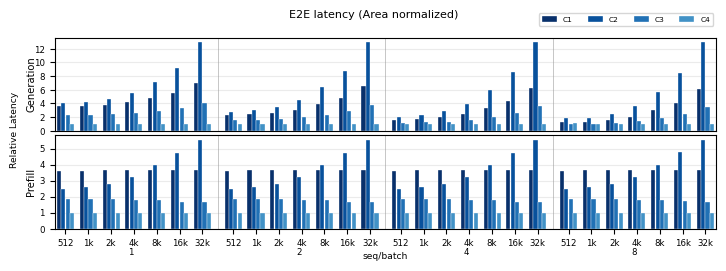

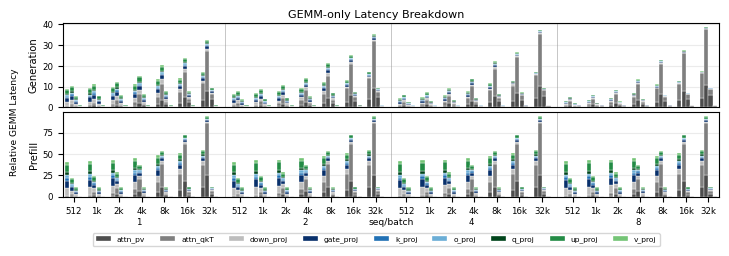

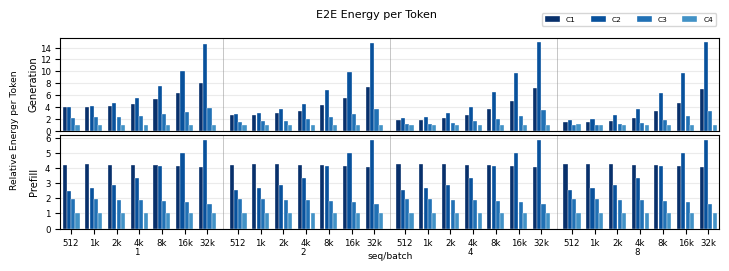

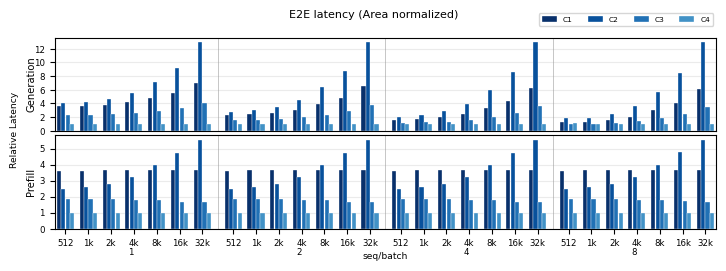

In [21]:
# Draw E2E latency from main_all_result.figure_data.

MAIN_ALL_KNOBS = WideBarKnobs(
    title_fontsize=TITLE_FONTSIZE,
    title_y=0.9,
    subplot_title_fontsize=SUBPLOT_TITLE_FONTSIZE,
    axis_label_fontsize=AXIS_LABEL_FONTSIZE,
    tick_label_fontsize=TICK_LABEL_FONTSIZE,
    legend_fontsize=LEGEND_FONTSIZE,
    legend_title_fontsize=LEGEND_TITLE_FONTSIZE,
    legend_title="", 
    legend_position="title_right",
    # title_right follows title_y by default. Use these to override/offset it.
    # legend_title_right_y=0.92,
    # legend_title_right_y_offset=0.0,
    # legend_bbox_to_anchor=(1, 0.92),
    value_labels=False,
    value_label_fontsize=VALUE_LABEL_FONTSIZE,
    value_label_rotation=VALUE_LABEL_ROTATION,
    auto_bar_width=True,
    x_candidate_group_gap=0.25,
    candidate_gap=0.01,
    x_pad_left=0.1,
    x_pad_right=0.1,
    # Per-row overrides are also supported.
    # stage_x_pad_left={"Generation": 0.5, "Prefill": 0.5},
    # stage_x_pad_right={"Generation": 0.5, "Prefill": 0.5},
    x_tick_visibility="last",
    x_tick_label_visibility="last",
    x_axis_label_visibility="last",
    x_label="seq/batch",
    x_axis_label_location="custom",
    x_axis_label_x=0.5,
    x_axis_label_y=-0.3,
    x_axis_label_ha="center",
    x_axis_label_va="center",
    x_axis_label_rotation=0.0,
    x_axis_label_fontsize=AXIS_LABEL_FONTSIZE,
    group_label_visibility="last",
    group_label_format="{batch}",
    group_label_x_position="center",
    # group_label_x_offset=-0.28,
    group_label_y=-0.25,
    group_label_ha="right",
    group_label_va="center",
    group_label_rotation=0.0,
    group_label_fontsize=TICK_LABEL_FONTSIZE,
    y_label="",
    figure_y_label="Relative Latency",
    figure_y_label_x=-0.001,
    figure_y_label_y=0.5,
    figure_y_label_fontsize=AXIS_LABEL_FONTSIZE,
    # Y grid/tick interval. Use global values or per-row stage overrides.
    # y_major_tick_interval=2.0,
    # y_minor_tick_interval=1.0,
    stage_y_major_tick_intervals={"Generation": 2.0, "Prefill": 1.0},
    # stage_y_minor_tick_intervals={"Generation": 1.0, "Prefill": 0.5},
    stage_label_position="left",
    stage_label_rotation=90.0,
    stage_label_x=-0.035,
    stage_label_y=0.5,
    stage_label_fontsize=SUBPLOT_TITLE_FONTSIZE,
    stage_label_ha="center",
    stage_label_va="center",
    y_lim_top_scale=1.05,
    figsize=(7.16, 3),
    # Increase/decrease vertical gap between subplot rows.
    subplot_hspace=0.05,
    # tight_layout_h_pad=0.8,
)

if DRAW_FIGURES:
    fig, axes, text_handles, fig_path = draw_wide_candidate_bars(
        main_all_result.figure_data,
        title="E2E latency (Area normalized)",
        out_dir=main_all_result.out_dir,
        filename="main_all_from_cache",
        knobs=MAIN_ALL_KNOBS,
    )
    main_all_result.figure_path = fig_path

## GEMM Only Plots

These cells use the plot API `row_filters` override so only workload cases with `kind == "gemm"` are included in aggregation, stacked bars, and exported CSVs.

In [22]:
GEMM_ONLY_FILTERS = (lambda df: df["kind"].eq("gemm"), exclude_c4_alone)

In [23]:
# main_gemm_only_result = run_suite_plot(
#     "main",
#     out_name="main_gemm_only",
#     figure_title="outputs_main / suites/main / GEMM only",
#     row_filters=GEMM_ONLY_FILTERS,
#     stacked=True,
#     include_c4_alone=False,
#     stack_legend_scope="global",
# )
# display_plot(main_gemm_only_result)
# main_gemm_only_result.plot_data.head()

In [24]:
# Build/load the GEMM-only figure CSV.
main_all_gemm_only_result = load_or_export_suite_figure_data(
    out_name="main_all_gemm_only",
    figure_title="GEMM Latency (ISO-area)",
    row_filters=GEMM_ONLY_FILTERS,
    stacked=True,
    include_c4_alone=False,
    stack_legend_scope="global",
    palette=GEMM_ONLY_STACK_PALETTE,
    legend_position="title_right",
)
print(f"figure data source: {main_all_gemm_only_result.cache_status}")
main_all_gemm_only_result.figure_data.head()


figure data source: cache


,stage,batch,seq,candidate,attn_pv,attn_qkT,down_proj,gate_proj,k_proj,o_proj,q_proj,up_proj,v_proj,total
0,Generation,1,512,C1,0.291119,0.407897,1.826147,1.927942,0.665479,0.665479,0.665479,1.927942,0.665479,9.042964
1,Generation,,,C2,0.666663,0.934084,1.950503,1.948738,0.735765,0.735765,0.735765,1.948738,0.735765,10.391786
2,Generation,,,C3,0.231666,0.233710,1.098755,1.097760,0.414470,0.414470,0.414470,1.097760,0.414470,5.417533
3,Generation,,,C4,0.245073,0.231286,0.114753,0.114609,0.044918,0.044918,0.044918,0.114609,0.044918,1.000000
4,Generation,1,1k,C1,0.418801,0.534753,1.854308,1.957673,0.675741,0.675741,0.675741,1.957673,0.675741,9.426171


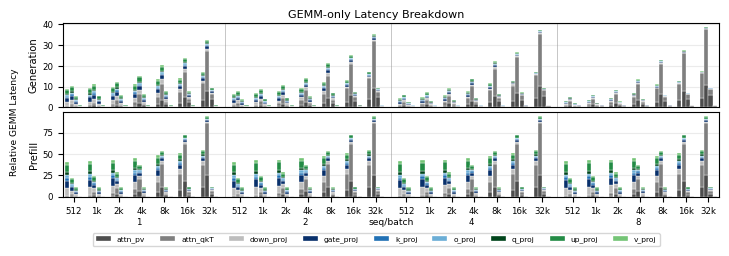

In [25]:
# Draw GEMM-only latency breakdown from main_all_gemm_only_result.figure_data.
GEMM_BREAKDOWN_KNOBS = StackedBarKnobs(
    title_fontsize=TITLE_FONTSIZE,
    title_x=0.5,
    title_y=0.85,
    subplot_title_fontsize=SUBPLOT_TITLE_FONTSIZE,
    axis_label_fontsize=AXIS_LABEL_FONTSIZE,
    tick_label_fontsize=TICK_LABEL_FONTSIZE,
    legend_fontsize=LEGEND_FONTSIZE,
    legend_title_fontsize=LEGEND_TITLE_FONTSIZE,
    legend_title="",
    legend_position="bottom",
    legend_ncol=9,
    legend_title_right_y=0.985,
    legend_bbox_to_anchor=(0.5, 0.1),
    value_labels=False,
    value_label_fontsize=VALUE_LABEL_FONTSIZE,
    value_label_rotation=VALUE_LABEL_ROTATION,
    auto_bar_width=True,
    x_candidate_group_gap=0.25,
    candidate_gap=0.01,
    x_pad_left=0.1,
    x_pad_right=0.1,
    x_tick_visibility="last",
    x_tick_label_visibility="last",
    x_axis_label_visibility="last",
    x_label="seq/batch",
    x_axis_label_location="custom",
    x_axis_label_x=0.5,
    x_axis_label_y=-0.3,
    x_axis_label_ha="center",
    x_axis_label_va="center",
    x_axis_label_rotation=0.0,
    x_axis_label_fontsize=AXIS_LABEL_FONTSIZE,
    group_label_visibility="last",
    group_label_format="{batch}",
    group_label_x_position="center",
    group_label_y=-0.30,
    group_label_ha="right",
    group_label_va="center",
    group_label_rotation=0.0,
    group_label_fontsize=TICK_LABEL_FONTSIZE,
    y_label="",
    figure_y_label="Relative GEMM Latency",
    figure_y_label_x=-0.005,
    figure_y_label_y=0.5,
    figure_y_label_fontsize=AXIS_LABEL_FONTSIZE,
    stage_y_major_tick_intervals={"Generation": 10.0, "Prefill": 25.0},
    stage_label_position="left",
    stage_label_rotation=90.0,
    stage_label_x=-0.045,
    stage_label_y=0.5,
    stage_label_fontsize=SUBPLOT_TITLE_FONTSIZE,
    stage_label_ha="center",
    stage_label_va="center",
    y_lim_top_scale=1.05,
    figsize=(7.16, 3.2),
    subplot_hspace=0.06,
)

if DRAW_FIGURES:
    fig, axes, text_handles, fig_path = draw_stacked_kernel_bars(
        main_all_gemm_only_result.figure_data,
        title="GEMM-only Latency Breakdown",
        out_dir=main_all_gemm_only_result.out_dir,
        filename="main_all_gemm_only_from_cache",
        knobs=GEMM_BREAKDOWN_KNOBS,
    )
    main_all_gemm_only_result.figure_path = fig_path

# Energy per token

In [26]:
# Energy per token
if str(LATENCY_DIR) not in sys.path:
    sys.path.insert(0, str(LATENCY_DIR))

from energy_per_token import add_relative_energy_values, energy_rows_from_records, plot_energy_per_token, summarize_energy_rows

ENERGY_IDLE_POWER_W = FPGA_IDLE_POWER
INCLUDE_IDLE_POWER = False
ENERGY_OUT_DIR = FIGURE_OUTPUT_ROOT / "energy_per_token"
ENERGY_CSV = ENERGY_OUT_DIR / FIGURE_DATA_CSV_NAME
energy_cache_status = "unknown"


def export_energy_figure_data(force_rebuild: bool | None = None) -> pd.DataFrame:
    global energy_cache_status
    force = FORCE_REBUILD_FIGURE_DATA if force_rebuild is None else force_rebuild
    if USE_FIGURE_DATA_CACHE and ENERGY_CSV.exists() and not force:
        energy_cache_status = "cache"
        return _read_figure_data(ENERGY_CSV)
    if "main_all_result" not in globals() or main_all_result.composed is None:
        # Cached latency CSV is enough for drawing latency, but energy needs composed kernel rows.
        rebuilt = export_suite_figure_data(
            out_name="main_all",
            figure_title="E2E latency (Area normalized)",
            stacked=False,
            include_c4_alone=False,
            legend_position="title_right",
            legend_ncol=4,
            legend_title="candidates",
        )
        composed = rebuilt.composed
    else:
        composed = main_all_result.composed
    records = list(composed.to_dict(orient="records")) if hasattr(composed, "to_dict") else list(composed)
    rows = energy_rows_from_records(
        records,
        RAW_DBS_POWER,
        idle_power_w=ENERGY_IDLE_POWER_W,
        include_idle_power=INCLUDE_IDLE_POWER,
    )
    summary = add_relative_energy_values(summarize_energy_rows(rows), relative_scope=RELATIVE_SCOPE)
    result = plot_script.EnergyExcelResult(summary=pd.DataFrame(summary), figure_path=ENERGY_OUT_DIR / "energy_per_token.png")
    plot_script.write_energy_figure_data_csv(result, label_maps=plot_label_maps(include_c4_alone=False))
    energy_cache_status = "rebuilt"
    return _read_figure_data(ENERGY_CSV)


energy_figure_data = export_energy_figure_data()
print(f"figure data source: {energy_cache_status}")
energy_figure_data.head()


figure data source: cache


,stage,batch,seq,C1,C2,C3,C4
0,Generation,1,512,3.936177,3.983709,2.215765,1.0
1,Generation,1,1k,4.032053,4.188130,2.273005,1.0
2,Generation,1,2k,4.217537,4.658279,2.351579,1.0
3,Generation,1,4k,4.569714,5.513418,2.527175,1.0
4,Generation,1,8k,5.406896,7.553292,2.851246,1.0


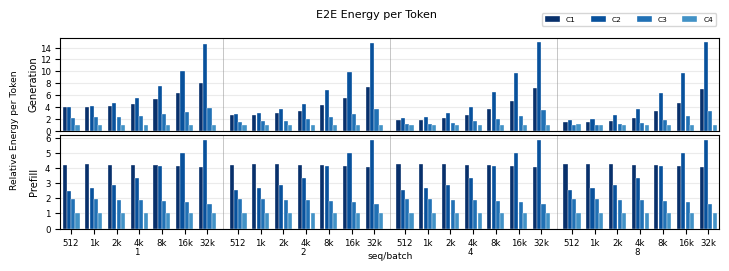

In [27]:
# Draw E2E energy per token from cached relative energy data.
ENERGY_PER_TOKEN_KNOBS = WideBarKnobs(
    title_fontsize=TITLE_FONTSIZE,
    title_y=0.9,
    subplot_title_fontsize=SUBPLOT_TITLE_FONTSIZE,
    axis_label_fontsize=AXIS_LABEL_FONTSIZE,
    tick_label_fontsize=TICK_LABEL_FONTSIZE,
    legend_fontsize=LEGEND_FONTSIZE,
    legend_title_fontsize=LEGEND_TITLE_FONTSIZE,
    legend_title="",
    legend_position="title_right",
    value_labels=False,
    value_label_fontsize=VALUE_LABEL_FONTSIZE,
    value_label_rotation=VALUE_LABEL_ROTATION,
    auto_bar_width=True,
    x_candidate_group_gap=0.25,
    candidate_gap=0.01,
    x_tick_visibility="last",
    x_tick_label_visibility="last",
    x_axis_label_visibility="last",
    x_label="seq/batch",
    x_axis_label_location="custom",
    x_axis_label_x=0.5,
    x_axis_label_y=-0.3,
    x_axis_label_ha="center",
    x_axis_label_va="center",
    x_axis_label_rotation=0.0,
    x_axis_label_fontsize=AXIS_LABEL_FONTSIZE,
    group_label_visibility="last",
    group_label_format="{batch}",
    group_label_x_position="center",
    group_label_y=-0.25,
    group_label_ha="right",
    group_label_va="center",
    group_label_rotation=0.0,
    group_label_fontsize=TICK_LABEL_FONTSIZE,
    y_label="",
    figure_y_label="Relative Energy per Token",
    figure_y_label_x=-0.005,
    figure_y_label_y=0.5,
    figure_y_label_fontsize=AXIS_LABEL_FONTSIZE,
    stage_y_major_tick_intervals={"Generation": 2.0, "Prefill": 1.0},
    stage_label_position="left",
    stage_label_rotation=90.0,
    stage_label_x=-0.040,
    stage_label_y=0.5,
    stage_label_fontsize=SUBPLOT_TITLE_FONTSIZE,
    stage_label_ha="center",
    stage_label_va="center",
    y_lim_top_scale=1.05,
    figsize=(7.16, 3),
    subplot_hspace=0.05,
    x_pad_left=0.1, x_pad_right=0.1,
)

if DRAW_FIGURES:
    fig, axes, text_handles, fig_path = draw_wide_candidate_bars(
        energy_figure_data,
        title="E2E Energy per Token",
        out_dir=ENERGY_OUT_DIR,
        filename="energy_per_token_from_cache",
        knobs=ENERGY_PER_TOKEN_KNOBS,
    )
    energy_result = PlotRunResult(
        tag="energy",
        out_dir=ENERGY_OUT_DIR,
        suites=[],
        options=None,
        versions=None,
        composed=None,
        plot_data=None,
        stack_data=None,
        figure_data=energy_figure_data,
        figure_path=fig_path,
        cache_status=energy_cache_status,
    )


# Llama2-7b VS Llama3-8b

In [28]:
LLAMA_COMPARE_OUT_DIR = FIGURE_OUTPUT_ROOT / "llama_compare"
LLAMA_COMPARE_CSV = LLAMA_COMPARE_OUT_DIR / "c1_vs_c4_speedup_batch1.csv"
LLAMA_COMPARE_CACHE_VERSION = "raw_roots_v2"
LLAMA_COMPARE_BATCH = 1
LLAMA_COMPARE_SEQ_ORDER = [512, 1024, 2048, 4096, 8192, 16384, 32768]
LLAMA_COMPARE_SEQ_LABELS = {
    512: "512",
    1024: "1k",
    2048: "2k",
    4096: "4k",
    8192: "8k",
    16384: "16k",
    32768: "32k",
}
LLAMA_COMPARE_STAGES = ("prefill", "generation")
LLAMA_COMPARE_MODELS = (
    {
        "model": "llama2-7b",
        "display_model": "Llama2-7B",
        "suite_prefix": "llama2_7b",
        "raw_db_roots": (LATENCY_DIR / "outputs_main",),
    },
    {
        "model": "llama3-8b",
        "display_model": "Llama3-8B",
        "suite_prefix": "llama3_8b",
        "raw_db_roots": (
            LATENCY_DIR / "outputs_main",
            LATENCY_DIR / "outputs_main",
        ),
    },
)
LLAMA_COMPARE_RAW_DB_SUBDIRS = (
    "naive_simd",
    "naive_gemm_tcol32",
    "improve_tcol32",
    "improve_no_tcu_lut_fexp",
)
LLAMA_COMPARE_SUITE_SUFFIXES = (
    "prefill_C1",
    "prefill_C2",
    "prefill_C3",
    "prefill_C4_alone",
    "prefill_C4_fused",
    "generation_C1",
    "generation_C2",
    "generation_C3",
    "generation_C4_alone",
    "generation_C4_fused",
)
LLAMA_COMPARE_C1_VARIANT = "all_sgemm_tcu_spinquant"
LLAMA_COMPARE_C4_VARIANT = C4_FUSED_VARIANT
LLAMA_COMPARE_FORCE_REBUILD = False


def _llama_compare_raw_dbs(raw_db_roots: tuple[Path, ...]) -> tuple[Path, ...]:
    return tuple(
        raw_db_root / subdir / "raw_db.csv"
        for raw_db_root in raw_db_roots
        for subdir in LLAMA_COMPARE_RAW_DB_SUBDIRS
    )


def _llama_compare_suite_paths(suite_prefix: str, tag: str = "main_all") -> tuple[Path, ...]:
    return tuple(
        LATENCY_DIR / "suites" / tag / f"{suite_prefix}_{suffix}.yaml"
        for suffix in LLAMA_COMPARE_SUITE_SUFFIXES
    )


def _require_existing_paths(paths) -> None:
    missing = [path for path in paths if not path.exists()]
    if missing:
        raise FileNotFoundError("missing llama comparison inputs:\n" + "\n".join(str(path) for path in missing))


def _numeric_int_column(frame: pd.DataFrame, column: str) -> pd.Series:
    return pd.to_numeric(frame[column], errors="coerce").astype("Int64")


def _compose_llama_compare_model(model_spec: dict) -> pd.DataFrame:
    suite_files = _llama_compare_suite_paths(model_spec["suite_prefix"])
    raw_dbs = _llama_compare_raw_dbs(model_spec["raw_db_roots"])
    _require_existing_paths((*suite_files, *raw_dbs))

    suites = [load_suite(path, repo_root=REPO_ROOT) for path in suite_files]
    options = SuiteBarPlotOptions(
        raw_dbs=raw_dbs,
        out_dir=LLAMA_COMPARE_OUT_DIR / f"_compose_{model_spec['suite_prefix']}",
        metric=METRIC,
        select=SELECT,
        missing=MISSING,
        x=X_AXIS,
        hue=HUE_AXIS,
        row=ROW_AXIS,
        col=COL_AXIS,
        stacked=False,
        stack_by=STACK_BY,
        value_labels=False,
        relative=False,
        share_y=False,
        legend_position="none",
        label_maps=plot_label_maps(include_c4_alone=False),
        value_orders=VALUE_ORDERS,
        latency_scale_rules=tuple(LATENCY_SCALE_RULES),
        case_latency_scale_rules=tuple(CASE_LATENCY_SCALE_RULES),
        latency_estimate=LATENCY_ESTIMATE,
        row_filters=(),
    )
    versions = prepare_suite_bar_data_versions(suites, options)
    plot_data = versions.final.plot_data.copy()
    plot_data["batch"] = _numeric_int_column(plot_data, "batch")
    plot_data["seq_len"] = _numeric_int_column(plot_data, "seq_len")
    plot_data["total_latency_us"] = pd.to_numeric(plot_data["total_latency_us"], errors="coerce")

    variants = {LLAMA_COMPARE_C1_VARIANT, LLAMA_COMPARE_C4_VARIANT}
    filtered = plot_data[
        plot_data["batch"].eq(LLAMA_COMPARE_BATCH)
        & plot_data["seq_len"].isin(LLAMA_COMPARE_SEQ_ORDER)
        & plot_data["stage"].isin(LLAMA_COMPARE_STAGES)
        & plot_data["variant"].isin(variants)
    ].copy()
    count_columns = [
        "case_count",
        "pass_case_count",
        "estimated_case_count",
        "missing_case_count",
    ]
    grouped = (
        filtered.groupby(["stage", "batch", "seq_len", "variant"], dropna=False, as_index=False)
        .agg(
            total_latency_us=("total_latency_us", "sum"),
            **{column: (column, "sum") for column in count_columns if column in filtered.columns},
        )
    )
    indexed = grouped.set_index(["stage", "batch", "seq_len", "variant"])

    records = []
    for stage in LLAMA_COMPARE_STAGES:
        for seq_len in LLAMA_COMPARE_SEQ_ORDER:
            c1_key = (stage, LLAMA_COMPARE_BATCH, seq_len, LLAMA_COMPARE_C1_VARIANT)
            c4_key = (stage, LLAMA_COMPARE_BATCH, seq_len, LLAMA_COMPARE_C4_VARIANT)
            if c1_key not in indexed.index:
                raise ValueError(f"missing C1 row for {model_spec['model']} {stage} seq_len={seq_len}")
            if c4_key not in indexed.index:
                raise ValueError(f"missing C4 row for {model_spec['model']} {stage} seq_len={seq_len}")
            c1 = indexed.loc[c1_key]
            c4 = indexed.loc[c4_key]
            c1_latency = float(c1["total_latency_us"])
            c4_latency = float(c4["total_latency_us"])
            if not math.isfinite(c1_latency) or c1_latency <= 0.0:
                raise ValueError(f"invalid C1 latency for {model_spec['model']} {stage} seq_len={seq_len}: {c1_latency}")
            if not math.isfinite(c4_latency) or c4_latency <= 0.0:
                raise ValueError(f"invalid C4 latency for {model_spec['model']} {stage} seq_len={seq_len}: {c4_latency}")
            record = {
                "model": model_spec["model"],
                "display_model": model_spec["display_model"],
                "stage": stage,
                "stage_label": LABEL_MAPS["stage"].get(stage, stage),
                "batch": LLAMA_COMPARE_BATCH,
                "seq_len": seq_len,
                "seq_label": LLAMA_COMPARE_SEQ_LABELS[seq_len],
                "seq_rank": LLAMA_COMPARE_SEQ_ORDER.index(seq_len),
                "c1_latency_us": c1_latency,
                "c4_latency_us": c4_latency,
                "c1_over_c4_speedup": c1_latency / c4_latency,
                "cache_version": LLAMA_COMPARE_CACHE_VERSION,
            }
            for column in count_columns:
                record[f"c1_{column}"] = int(c1[column]) if column in c1 else 0
                record[f"c4_{column}"] = int(c4[column]) if column in c4 else 0
            records.append(record)
    return pd.DataFrame.from_records(records)


def build_llama_compare_speedup() -> pd.DataFrame:
    frames = [_compose_llama_compare_model(model_spec) for model_spec in LLAMA_COMPARE_MODELS]
    out = pd.concat(frames, ignore_index=True)
    out = out.sort_values(["stage", "model", "seq_rank"]).reset_index(drop=True)
    expected_rows = len(LLAMA_COMPARE_MODELS) * len(LLAMA_COMPARE_STAGES) * len(LLAMA_COMPARE_SEQ_ORDER)
    if len(out) != expected_rows:
        raise ValueError(f"expected {expected_rows} comparison rows, got {len(out)}")
    if out["c1_over_c4_speedup"].isna().any() or (out["c1_over_c4_speedup"] <= 0).any():
        raise ValueError("speedup values must be finite and positive")
    LLAMA_COMPARE_OUT_DIR.mkdir(parents=True, exist_ok=True)
    out.to_csv(LLAMA_COMPARE_CSV, index=False)
    return out


def _llama_compare_cache_is_current(data: pd.DataFrame) -> bool:
    return "cache_version" in data.columns and data["cache_version"].eq(LLAMA_COMPARE_CACHE_VERSION).all()


def load_or_build_llama_compare_speedup() -> pd.DataFrame:
    if LLAMA_COMPARE_CSV.exists() and not LLAMA_COMPARE_FORCE_REBUILD:
        cached = pd.read_csv(LLAMA_COMPARE_CSV)
        if _llama_compare_cache_is_current(cached):
            print(f"comparison data source: cached {LLAMA_COMPARE_CSV}")
            return cached
        print(f"comparison data source: stale cache {LLAMA_COMPARE_CSV}; rebuilding")
    else:
        print("comparison data source: rebuilt from suites and raw DBs")
    return build_llama_compare_speedup()


llama_compare_speedup = load_or_build_llama_compare_speedup()
print(f"wrote {LLAMA_COMPARE_CSV}")
print(f"rows: {len(llama_compare_speedup)}")
display(llama_compare_speedup)


comparison data source: rebuilt from suites and raw DBs
wrote /home/jaeyongjang/project.local/vortex/analysis_workspace/latency_on_hw/outputs_main/figures_notebook/llama_compare/c1_vs_c4_speedup_batch1.csv
rows: 28


,model,display_model,stage,stage_label,batch,seq_len,seq_label,seq_rank,c1_latency_us,c4_latency_us,c1_over_c4_speedup,cache_version,c1_case_count,c4_case_count,c1_pass_case_count,c4_pass_case_count,c1_estimated_case_count,c4_estimated_case_count,c1_missing_case_count,c4_missing_case_count
0,llama2-7b,Llama2-7B,generation,Generation,1,512,512,0,9.410115e+07,2.653511e+07,3.546289,raw_roots_v2,24,28,24,28,0,0,0,0
1,llama2-7b,Llama2-7B,generation,Generation,1,1024,1k,1,9.641176e+07,2.645897e+07,3.643821,raw_roots_v2,24,28,24,28,0,0,0,0
2,llama2-7b,Llama2-7B,generation,Generation,1,2048,2k,2,1.019568e+08,2.674272e+07,3.812507,raw_roots_v2,24,28,24,28,0,0,0,0
3,llama2-7b,Llama2-7B,generation,Generation,1,4096,4k,3,1.131707e+08,2.708881e+07,4.177765,raw_roots_v2,24,28,24,28,0,0,0,0
4,llama2-7b,Llama2-7B,generation,Generation,1,8192,8k,4,1.350610e+08,2.794926e+07,4.832365,raw_roots_v2,24,28,19,25,5,3,0,0
5,llama2-7b,Llama2-7B,generation,Generation,1,16384,16k,5,1.789999e+08,3.229319e+07,5.542961,raw_roots_v2,24,28,19,25,5,3,0,0
6,llama2-7b,Llama2-7B,generation,Generation,1,32768,32k,6,2.668777e+08,3.825508e+07,6.976268,raw_roots_v2,24,28,19,25,5,3,0,0
7,llama3-8b,Llama3-8B,generation,Generation,1,512,512,0,8.573018e+07,1.369115e+07,6.261721,raw_roots_v2,24,28,24,28,0,0,0,0
8,llama3-8b,Llama3-8B,generation,Generation,1,1024,1k,1,8.633377e+07,1.373280e+07,6.286681,raw_roots_v2,24,28,24,28,0,0,0,0
9,llama3-8b,Llama3-8B,generation,Generation,1,2048,2k,2,8.785309e+07,1.401395e+07,6.268975,raw_roots_v2,24,28,24,28,0,0,0,0


wrote /home/jaeyongjang/project.local/vortex/analysis_workspace/latency_on_hw/outputs_main/figures_notebook/llama_compare/c1_vs_c4_speedup_batch1.png
wrote /home/jaeyongjang/project.local/vortex/analysis_workspace/latency_on_hw/outputs_main/figures_notebook/llama_compare/c1_vs_c4_speedup_batch1.pdf


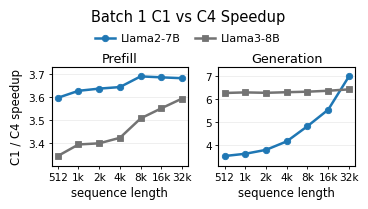

In [29]:
LLAMA_COMPARE_PNG = LLAMA_COMPARE_OUT_DIR / "c1_vs_c4_speedup_batch1.png"
LLAMA_COMPARE_PDF = LLAMA_COMPARE_OUT_DIR / "c1_vs_c4_speedup_batch1.pdf"


@dataclass
class LlamaCompareKnobs:
    figsize: tuple[float, float] = (3.45, 2.50)
    save_dpi: int = 240
    colors: dict[str, str] = field(default_factory=lambda: {
        "llama2-7b": "#1F77B4",
        "llama3-8b": "#737373",
    })
    markers: dict[str, str] = field(default_factory=lambda: {
        "llama2-7b": "o",
        "llama3-8b": "s",
    })
    line_width: float = 1.8
    marker_size: float = 4.6
    marker_edge_width: float = 0.6
    marker_facecolor: str | dict[str, str] | None = None
    marker_edgecolor: str | dict[str, str] | None = None
    title: str = "Batch 1 C1 vs C4 Speedup"
    show_title: bool = True
    title_fontsize: float = 10.5
    title_x: float = 0.5
    title_y: float = 0.83
    title_ha: str = "center"
    title_va: str = "top"
    subplot_title_fontsize: float = 9.2
    subplot_title_pad: float = 3.5
    axis_label_fontsize: float = 8.4
    tick_label_fontsize: float = 7.6
    x_label: str = "sequence length"
    y_label: str = "C1 / C4 speedup"
    x_label_pad: float = 3.0
    y_label_pad: float = 4.0
    x_label_coords: tuple[float, float] | None = None
    y_label_coords: tuple[float, float] | None = None
    x_tick_rotation: float = 0.0
    x_tick_pad: float = 2.0
    y_tick_pad: float = 2.0
    tick_length: float = 2.5
    tick_width: float = 0.6
    share_y: bool = False
    y_lim: tuple[float, float] | None = None
    stage_y_lims: dict[str, tuple[float, float]] = field(default_factory=dict)
    y_pad_fraction: float = 0.12
    y_min_floor: float | None = None
    y_max_ceil: float | None = None
    y_major_tick_interval: float | None = None
    y_minor_tick_interval: float | None = None
    grid_major_interval: float | None = None
    grid_minor_interval: float | None = None
    stage_y_major_tick_intervals: dict[str, float] = field(default_factory=lambda: {
        "prefill": 0.2,
        "generation": 1.0,
    })
    stage_y_minor_tick_intervals: dict[str, float] = field(default_factory=dict)
    stage_grid_major_intervals: dict[str, float] = field(default_factory=lambda: {
        "prefill": 0.2,
        "generation": 1.0,
    })
    stage_grid_minor_intervals: dict[str, float] = field(default_factory=dict)
    show_baseline: bool = False
    include_baseline_in_ylim: bool = False
    baseline_y: float = 1.0
    baseline_color: str = "#5C5C5C"
    baseline_linewidth: float = 0.7
    baseline_linestyle: str = "--"
    grid_axis: str = "y"
    grid_alpha: float = 0.28
    grid_linewidth: float = 0.55
    grid_color: str = "#B8B8B8"
    grid_minor: bool = False
    grid_minor_alpha: float = 0.12
    spine_linewidth: float = 0.8
    show_top_spine: bool = True
    show_right_spine: bool = True
    legend_visible: bool = True
    legend_loc: str = "upper center"
    legend_bbox_to_anchor: tuple[float, float] = (0.5, 0.750)
    legend_ncol: int = 2
    legend_fontsize: float = 8.0
    legend_frameon: bool = False
    legend_handlelength: float = 1.8
    legend_handletextpad: float = 0.5
    legend_columnspacing: float = 1.3
    legend_labelspacing: float = 0.35
    legend_borderaxespad: float = 0.0
    layout_left: float = 0.105
    layout_right: float = 0.985
    layout_bottom: float = 0.205
    layout_top: float = 0.600
    layout_wspace: float = 0.22
    save_bbox_inches: str | None = "tight"
    save_pad_inches: float = 0.025


LLAMA_COMPARE_KNOBS = LlamaCompareKnobs(
  stage_grid_major_intervals={"prefill": 0.1, "generation": 1.0}
)

def _llama_compare_resolve(value, key: str, default=None):
    if isinstance(value, dict):
        return value.get(key, default)
    return default if value is None else value


def _llama_compare_ticks(limits: tuple[float, float], interval: float | None) -> list[float] | None:
    if interval is None or interval <= 0:
        return None
    lo, hi = limits
    start = math.ceil((lo - 1e-9) / interval) * interval
    ticks = []
    value = start
    while value <= hi + 1e-9:
        ticks.append(round(value, 10))
        value += interval
    return ticks


def _llama_compare_auto_ylim(values: pd.Series, knobs: LlamaCompareKnobs) -> tuple[float, float]:
    numeric = pd.to_numeric(values, errors="coerce").dropna()
    if knobs.show_baseline and knobs.include_baseline_in_ylim:
        numeric = pd.concat([numeric, pd.Series([knobs.baseline_y])], ignore_index=True)
    if numeric.empty:
        return (0.0, 1.0)
    lo = float(numeric.min())
    hi = float(numeric.max())
    span = hi - lo
    if not math.isfinite(span) or span <= 0.0:
        span = max(abs(hi), 1.0) * 0.1
    pad = span * knobs.y_pad_fraction
    lo -= pad
    hi += pad
    if knobs.y_min_floor is not None:
        lo = max(lo, knobs.y_min_floor)
    if knobs.y_max_ceil is not None:
        hi = min(hi, knobs.y_max_ceil)
    if hi <= lo:
        hi = lo + max(abs(lo), 1.0) * 0.1
    return lo, hi


def _llama_compare_stage_ylim(stage_df: pd.DataFrame, stage: str, knobs: LlamaCompareKnobs) -> tuple[float, float]:
    if knobs.y_lim is not None:
        return knobs.y_lim
    if stage in knobs.stage_y_lims:
        return knobs.stage_y_lims[stage]
    return _llama_compare_auto_ylim(stage_df["c1_over_c4_speedup"], knobs)


def _llama_compare_apply_y_ticks(ax, stage: str, y_lim: tuple[float, float], knobs: LlamaCompareKnobs) -> None:
    major_interval = knobs.stage_grid_major_intervals.get(stage, knobs.grid_major_interval)
    if major_interval is None:
        major_interval = knobs.stage_y_major_tick_intervals.get(stage, knobs.y_major_tick_interval)
    minor_interval = knobs.stage_grid_minor_intervals.get(stage, knobs.grid_minor_interval)
    if minor_interval is None:
        minor_interval = knobs.stage_y_minor_tick_intervals.get(stage, knobs.y_minor_tick_interval)
    major_ticks = _llama_compare_ticks(y_lim, major_interval)
    minor_ticks = _llama_compare_ticks(y_lim, minor_interval)
    if major_ticks is not None:
        ax.set_yticks(major_ticks)
    if minor_ticks is not None:
        ax.set_yticks(minor_ticks, minor=True)


def plot_llama_compare_speedup(data: pd.DataFrame, knobs: LlamaCompareKnobs = LLAMA_COMPARE_KNOBS):
    plot_df = data.copy()
    plot_df["seq_rank"] = pd.to_numeric(plot_df["seq_rank"], errors="coerce")
    fig, axes_arr = plt.subplots(
        1,
        len(LLAMA_COMPARE_STAGES),
        figsize=knobs.figsize,
        sharey=knobs.share_y,
        squeeze=False,
    )
    axes = axes_arr[0]
    global_y_lim = knobs.y_lim
    if knobs.share_y and global_y_lim is None:
        global_y_lim = _llama_compare_auto_ylim(plot_df["c1_over_c4_speedup"], knobs)

    for ax, stage in zip(axes, LLAMA_COMPARE_STAGES):
        stage_df = plot_df[plot_df["stage"].eq(stage)]
        for model_spec in LLAMA_COMPARE_MODELS:
            model = model_spec["model"]
            model_df = stage_df[stage_df["model"].eq(model)].sort_values("seq_rank")
            color = knobs.colors.get(model, "#333333")
            marker_facecolor = _llama_compare_resolve(knobs.marker_facecolor, model, color)
            marker_edgecolor = _llama_compare_resolve(knobs.marker_edgecolor, model, color)
            ax.plot(
                model_df["seq_label"],
                model_df["c1_over_c4_speedup"],
                marker=knobs.markers.get(model, "o"),
                linewidth=knobs.line_width,
                markersize=knobs.marker_size,
                markeredgewidth=knobs.marker_edge_width,
                markerfacecolor=marker_facecolor,
                markeredgecolor=marker_edgecolor,
                color=color,
                label=model_spec["display_model"],
            )
        if knobs.show_baseline:
            ax.axhline(
                knobs.baseline_y,
                color=knobs.baseline_color,
                linewidth=knobs.baseline_linewidth,
                linestyle=knobs.baseline_linestyle,
            )
        stage_label = LABEL_MAPS["stage"].get(stage, stage)
        ax.set_title(stage_label, fontsize=knobs.subplot_title_fontsize, pad=knobs.subplot_title_pad)
        ax.set_xlabel(knobs.x_label, fontsize=knobs.axis_label_fontsize, labelpad=knobs.x_label_pad)
        if knobs.x_label_coords is not None:
            ax.xaxis.set_label_coords(*knobs.x_label_coords)
        ax.tick_params(
            axis="both",
            labelsize=knobs.tick_label_fontsize,
            length=knobs.tick_length,
            width=knobs.tick_width,
            pad=knobs.y_tick_pad,
        )
        ax.tick_params(axis="x", labelrotation=knobs.x_tick_rotation, pad=knobs.x_tick_pad)
        y_lim = global_y_lim if global_y_lim is not None else _llama_compare_stage_ylim(stage_df, stage, knobs)
        ax.set_ylim(*y_lim)
        _llama_compare_apply_y_ticks(ax, stage, y_lim, knobs)
        ax.grid(axis=knobs.grid_axis, color=knobs.grid_color, alpha=knobs.grid_alpha, linewidth=knobs.grid_linewidth)
        if knobs.grid_minor:
            ax.grid(axis=knobs.grid_axis, which="minor", color=knobs.grid_color, alpha=knobs.grid_minor_alpha, linewidth=knobs.grid_linewidth)
        for spine_name, spine in ax.spines.items():
            spine.set_linewidth(knobs.spine_linewidth)
            if spine_name == "top":
                spine.set_visible(knobs.show_top_spine)
            if spine_name == "right":
                spine.set_visible(knobs.show_right_spine)

    axes[0].set_ylabel(knobs.y_label, fontsize=knobs.axis_label_fontsize, labelpad=knobs.y_label_pad)
    if knobs.y_label_coords is not None:
        axes[0].yaxis.set_label_coords(*knobs.y_label_coords)
    if knobs.legend_visible:
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(
            handles,
            labels,
            loc=knobs.legend_loc,
            bbox_to_anchor=knobs.legend_bbox_to_anchor,
            ncol=knobs.legend_ncol,
            frameon=knobs.legend_frameon,
            fontsize=knobs.legend_fontsize,
            handlelength=knobs.legend_handlelength,
            handletextpad=knobs.legend_handletextpad,
            columnspacing=knobs.legend_columnspacing,
            labelspacing=knobs.legend_labelspacing,
            borderaxespad=knobs.legend_borderaxespad,
        )
    if knobs.show_title:
        fig.suptitle(
            knobs.title,
            fontsize=knobs.title_fontsize,
            x=knobs.title_x,
            y=knobs.title_y,
            ha=knobs.title_ha,
            va=knobs.title_va,
        )
    fig.subplots_adjust(
        left=knobs.layout_left,
        right=knobs.layout_right,
        bottom=knobs.layout_bottom,
        top=knobs.layout_top,
        wspace=knobs.layout_wspace,
    )
    LLAMA_COMPARE_OUT_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(
        LLAMA_COMPARE_PNG,
        dpi=knobs.save_dpi,
        bbox_inches=knobs.save_bbox_inches,
        pad_inches=knobs.save_pad_inches,
    )
    fig.savefig(LLAMA_COMPARE_PDF, bbox_inches=knobs.save_bbox_inches, pad_inches=knobs.save_pad_inches)
    return fig, axes, LLAMA_COMPARE_PNG, LLAMA_COMPARE_PDF


fig, axes, llama_compare_png, llama_compare_pdf = plot_llama_compare_speedup(llama_compare_speedup)
print(f"wrote {llama_compare_png}")
print(f"wrote {llama_compare_pdf}")
if DISPLAY_FIGURES:
    display(fig)
plt.close(fig)


# Layout Transform Overhead Analysis

Layout fused kernels combine the original vector operation with a layout conversion at the GEMM boundary.

This analysis compares measured `baseline_app` vs `layout_fused_app` rows with the same logical shape. The match key is `(fpga_bin_label, canonical_app, name, canonical_shape_json)`, where `canonical_shape_json` removes layout-only metadata such as `layout_from`, `layout_to`, `producer`, and `consumer`. This catches cases like `rmsnorm` vs `rms_norm_layout_fused`, where CLI args differ (`-batch/-seq/-hidden` vs `-m/-k`) but the logical tensor shape is identical.


In [30]:
# import json
# import math
# import pandas as pd
# import matplotlib.pyplot as plt

# LAYOUT_OVERHEAD_OUT_DIR = LATENCY_DIR / "outputs_main" / "figures_notebook" / "layout_transform_overhead"
# LAYOUT_OVERHEAD_OUT_DIR.mkdir(parents=True, exist_ok=True)

# LAYOUT_FUSED_APP_MAP = {
#     "eladd_layout_fused": "eladd",
#     "elmul_layout_fused": "elmul",
#     "head_concat_layout_fused": "head_concat",
#     "kv_cache_quant_layout_fused_w4a16": "kv_cache_quant_w4a16",
#     "rms_norm_layout_fused": "rmsnorm",
#     "rope_layout_fused": "rope",
#     "silu_layout_fused": "silu",
#     "softmax_layout_fused": "softmax",
# }

# LAYOUT_SHAPE_DROP_KEYS = {
#     "consumer",
#     "layout_from",
#     "layout_group",
#     "layout_to",
#     "producer",
#     "qparam_layout_to",
#     "scale_zp_layout_to",
#     "weight_layout_to",
# }


# def _parse_shape_json(value) -> dict:
#     if isinstance(value, dict):
#         return dict(value)
#     if not isinstance(value, str) or not value.strip():
#         return {}
#     return json.loads(value)


# def _canonical_layout_app(app: str) -> str:
#     app = str(app)
#     if app in LAYOUT_FUSED_APP_MAP:
#         return LAYOUT_FUSED_APP_MAP[app]
#     if app.endswith("_layout_fused"):
#         return app[: -len("_layout_fused")]
#     return app


# def _layout_mode(app: str) -> str:
#     app = str(app)
#     return "layout_fused" if app in LAYOUT_FUSED_APP_MAP or app.endswith("_layout_fused") else "baseline"


# def _canonical_shape(shape: dict) -> dict:
#     out = {k: v for k, v in shape.items() if k not in LAYOUT_SHAPE_DROP_KEYS}

#     # Remove redundant GEMM aliases when the logical vector shape is present.
#     if {"batch", "seq", "hidden", "M", "K"}.issubset(out):
#         if out.get("M") == out.get("batch") * out.get("seq"):
#             out.pop("M", None)
#         if out.get("K") == out.get("hidden"):
#             out.pop("K", None)

#     # Elementwise fused kernels often use M/K args while baseline kernels use size.
#     if {"size", "M", "K"}.issubset(out):
#         if out.get("size") == out.get("M") * out.get("K"):
#             out.pop("M", None)
#             out.pop("K", None)

#     return dict(sorted(out.items(), key=lambda item: item[0]))


# def _canonical_shape_json(shape: dict) -> str:
#     return json.dumps(_canonical_shape(shape), sort_keys=True, separators=(",", ":"))


# def load_layout_overhead_rows(raw_dbs=RAW_DBS_OUTPUT_MAIN, metric: str = METRIC) -> pd.DataFrame:
#     frames = []
#     for raw_db in raw_dbs:
#         df = pd.read_csv(raw_db)
#         df["raw_db"] = str(raw_db)
#         frames.append(df)
#     raw = pd.concat(frames, ignore_index=True)
#     raw = raw[(raw["status"].astype(str) == "pass") & pd.to_numeric(raw[metric], errors="coerce").notna()].copy()
#     raw[metric] = pd.to_numeric(raw[metric], errors="coerce")
#     raw["layout_mode"] = raw["app"].map(_layout_mode)
#     raw["canonical_app"] = raw["app"].map(_canonical_layout_app)
#     raw = raw[raw["layout_mode"].isin({"baseline", "layout_fused"})].copy()
#     raw["shape_dict"] = raw["shape_json"].map(_parse_shape_json)
#     raw["canonical_shape_dict"] = raw["shape_dict"].map(_canonical_shape)
#     raw["canonical_shape_json"] = raw["shape_dict"].map(_canonical_shape_json)
#     raw["latency_us"] = raw[metric]

#     key_cols = ["fpga_bin_label", "canonical_app", "name", "canonical_shape_json"]
#     baseline = raw[raw["layout_mode"] == "baseline"].copy()
#     fused = raw[raw["layout_mode"] == "layout_fused"].copy()
#     baseline = baseline.sort_values("timestamp_utc").drop_duplicates(key_cols, keep="last")
#     fused = fused.sort_values("timestamp_utc").drop_duplicates(key_cols, keep="last")

#     cols = [
#         *key_cols,
#         "app",
#         "args",
#         "shape_json",
#         "canonical_shape_dict",
#         "latency_us",
#         "run_id",
#         "case_id",
#         "raw_db",
#     ]
#     pairs = baseline[cols].merge(
#         fused[cols],
#         on=key_cols,
#         how="inner",
#         suffixes=("_baseline", "_layout_fused"),
#     )
#     pairs = pairs.rename(
#         columns={
#             "app_baseline": "baseline_app",
#             "args_baseline": "baseline_args",
#             "shape_json_baseline": "baseline_shape_json",
#             "latency_us_baseline": "baseline_us",
#             "run_id_baseline": "baseline_run_id",
#             "case_id_baseline": "baseline_case_id",
#             "raw_db_baseline": "baseline_raw_db",
#             "app_layout_fused": "layout_fused_app",
#             "args_layout_fused": "layout_fused_args",
#             "shape_json_layout_fused": "layout_fused_shape_json",
#             "latency_us_layout_fused": "layout_fused_us",
#             "run_id_layout_fused": "layout_fused_run_id",
#             "case_id_layout_fused": "layout_fused_case_id",
#             "raw_db_layout_fused": "layout_fused_raw_db",
#         }
#     )
#     if pairs.empty:
#         return pairs
#     pairs["overhead_us"] = pairs["layout_fused_us"] - pairs["baseline_us"]
#     pairs["overhead_pct"] = 100.0 * pairs["overhead_us"] / pairs["baseline_us"]
#     pairs["layout_fused_over_baseline"] = pairs["layout_fused_us"] / pairs["baseline_us"]
#     pairs["logical_shape"] = pairs["canonical_shape_dict_baseline"].map(lambda x: json.dumps(x, sort_keys=True))
#     return pairs.sort_values(["canonical_app", "name", "logical_shape"]).reset_index(drop=True)


# def summarize_layout_overhead(overhead: pd.DataFrame) -> pd.DataFrame:
#     if overhead.empty:
#         return overhead
#     return (
#         overhead.groupby(["fpga_bin_label", "canonical_app", "baseline_app", "layout_fused_app"], dropna=False)
#         .agg(
#             pairs=("overhead_us", "size"),
#             baseline_us_median=("baseline_us", "median"),
#             layout_fused_us_median=("layout_fused_us", "median"),
#             overhead_us_median=("overhead_us", "median"),
#             overhead_pct_median=("overhead_pct", "median"),
#             overhead_pct_mean=("overhead_pct", "mean"),
#             overhead_pct_min=("overhead_pct", "min"),
#             overhead_pct_max=("overhead_pct", "max"),
#             ratio_median=("layout_fused_over_baseline", "median"),
#         )
#         .reset_index()
#         .sort_values(["overhead_pct_median", "canonical_app"], ascending=[False, True])
#     )


In [31]:
# layout_overhead = load_layout_overhead_rows()
# layout_overhead_summary = summarize_layout_overhead(layout_overhead)

# layout_overhead_csv = LAYOUT_OVERHEAD_OUT_DIR / "layout_transform_overhead.csv"
# layout_overhead_summary_csv = LAYOUT_OVERHEAD_OUT_DIR / "layout_transform_overhead_summary.csv"
# layout_overhead.to_csv(layout_overhead_csv, index=False)
# layout_overhead_summary.to_csv(layout_overhead_summary_csv, index=False)

# print(f"matched baseline/layout_fused pairs: {len(layout_overhead)}")
# print(f"wrote {layout_overhead_csv}")
# print(f"wrote {layout_overhead_summary_csv}")
# display(layout_overhead_summary)


In [32]:
# # Detailed per-shape rows. Adjust these filters while debugging.
# layout_overhead_view = layout_overhead.copy()
# # layout_overhead_view = layout_overhead_view[layout_overhead_view["canonical_app"].eq("softmax")]
# # layout_overhead_view = layout_overhead_view[layout_overhead_view["overhead_pct"].abs().gt(20)]

# cols = [
#     "fpga_bin_label",
#     "canonical_app",
#     "name",
#     "baseline_app",
#     "layout_fused_app",
#     "baseline_us",
#     "layout_fused_us",
#     "overhead_us",
#     "overhead_pct",
#     "layout_fused_over_baseline",
#     "logical_shape",
#     "baseline_args",
#     "layout_fused_args",
# ]
# display(
#     layout_overhead_view[cols]
#     .sort_values(["canonical_app", "name", "logical_shape"])
#     .reset_index(drop=True)
# )


In [33]:
# if not layout_overhead_summary.empty:
#     plot_df = layout_overhead_summary.sort_values("overhead_pct_median", ascending=True)
#     fig, ax = plt.subplots(figsize=(10, max(3.5, 0.45 * len(plot_df))))
#     labels = plot_df["canonical_app"] + "\n" + plot_df["layout_fused_app"]
#     bars = ax.barh(labels, plot_df["overhead_pct_median"], color="#087E8B")
#     ax.axvline(0, color="#333333", linewidth=0.8)
#     ax.set_xlabel("median overhead vs baseline (%)")
#     ax.set_title("Layout fused overhead by canonical app")
#     ax.grid(axis="x", alpha=0.25)
#     for bar, value in zip(bars, plot_df["overhead_pct_median"]):
#         x = bar.get_width()
#         ha = "left" if x >= 0 else "right"
#         dx = 1.0 if x >= 0 else -1.0
#         ax.text(x + dx, bar.get_y() + bar.get_height() / 2, f"{value:.1f}%", va="center", ha=ha, fontsize=8)
#     fig.tight_layout()
#     fig_path = LAYOUT_OVERHEAD_OUT_DIR / "layout_transform_overhead_median_pct.png"
#     fig.savefig(fig_path, dpi=200, bbox_inches="tight")
#     print(f"wrote {fig_path}")
#     display(fig)
